# Chapter 1 — Simulation study: when is structured corruption recoverable?

Chapter 0 defines and validates the Bayesian corruption model. This notebook uses controlled simulations to examine the conditions under which the corruption mechanism can be recovered and corrupted observations can be localised.

The scientific corruption region is the hard halfspace

$$
R = \{x : \alpha^\top x > c\},
$$

and all simulations use the one-sided $1 \to 0$ corruption mechanism.

The fitted model is kept fixed while different parts of the data-generating process are varied:

- sample size and the realised number of corruptions;
- corruption probability \(q\);
- the size and distribution of the susceptible population;
- boundary geometry when \(\alpha\) must also be estimated.

Experiments 1–3 use the axis-supplied model, where the boundary direction is known and only the threshold \(c\) is estimated. These experiments study sample information, corruption strength and susceptible-region structure.

Experiments 4a and 4b use the general-boundary model, where \(\alpha\) is estimated jointly. These experiments focus on the additional difficulty of learning the boundary orientation.

Experiments 1–3 use 20 independently generated datasets per setting. The learned-boundary experiments use 10 datasets per condition. Recovery summaries are interpreted only for fits that pass the prespecified sampler diagnostic checks.

Regenerated outputs are saved under `high_replication/`.

## 0. Setup

In [1]:
# Set up dependencies and output folders.
import sys
import subprocess
from pathlib import Path


# Install anything missing from the current environment.
for package, import_name in [
    ("cmdstanpy", "cmdstanpy"),
    ("cleanlab", "cleanlab"),
]:
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                package,
            ]
        )


from cmdstanpy import cmdstan_path, install_cmdstan


# Install CmdStan only if it is not already available.
try:
    _ = cmdstan_path()
except Exception:
    print("CmdStan not found; installing...")
    install_cmdstan(
        cores=2,
        progress=True,
    )


# Keep regenerated outputs separate from the original dissertation files.
HIGHREP_ROOT = Path("high_replication")
REPLICATE_DIR = HIGHREP_ROOT / "replicate_results"
FIGURE_DIR = HIGHREP_ROOT / "figures"

HIGHREP_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

REPLICATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "High-rep outputs:",
    HIGHREP_ROOT.resolve(),
)

print(
    "Replicate checkpoints:",
    REPLICATE_DIR.resolve(),
)

High-rep outputs: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication
Replicate checkpoints: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/replicate_results


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from cleanlab.rank import get_label_quality_scores
from cmdstanpy import CmdStanModel


# Ignore the occasional numerical warning from matrix operations.
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message=".*encountered in matmul"
)


# Shared simulation settings.
SEED = 2026
KAPPA = 5.0

BETA0_TRUE = -0.8
BETA_TRUE = np.array(
    [1.5, -1.2, 0.8, -0.6, 0.0],
    dtype=np.float64,
)


# Stan models from Chapter 0.
AXIS_STAN_FILE = Path(
    "corruption_model_axis_FINAL.stan"
)

GENERAL_STAN_FILE = Path(
    "corruption_model_general_FINAL.stan"
)


# Leave this False for the full simulation runs.
QUICK_MODE = False

if QUICK_MODE:
    # Smaller settings for checking that the notebook runs through.
    CHAINS = 2
    WARMUP = 300
    SAMPLES = 300
    REPS = 1
else:
    # Main settings for Experiments 1–3.
    CHAINS = 4
    WARMUP = 1000
    SAMPLES = 1000
    REPS = 20


# Learned-boundary fits use the longer four-chain setup.
GENERAL_CHAINS = 4
GENERAL_WARMUP = 1000
GENERAL_SAMPLES = 1000


print(
    f"QUICK_MODE={QUICK_MODE} | "
    f"chains={CHAINS} | "
    f"warmup={WARMUP} | "
    f"samples={SAMPLES} | "
    f"reps={REPS} | "
    f"general={GENERAL_CHAINS}x"
    f"({GENERAL_WARMUP}+{GENERAL_SAMPLES})"
)

QUICK_MODE=False | chains=4 | warmup=1000 | samples=1000 | reps=20 | general=4x(1000+1000)


In [3]:
# Check that the Chapter 0 Stan models are available.
for stan_file in [
    AXIS_STAN_FILE,
    GENERAL_STAN_FILE,
]:
    if not stan_file.exists():
        raise FileNotFoundError(
            f"Missing {stan_file}"
        )

print("Stan model files found.")

Stan model files found.


In [4]:
# Keep the simulation figures consistent.
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.titleweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "lines.linewidth": 1.8,
    "lines.markersize": 5.5,
    "errorbar.capsize": 3,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

## 1. Data generation

The latent response model is the same as in Chapter 0,

$$
y_i' \mid x_i \sim \mathrm{Bernoulli}(p_i),
\qquad
\mathrm{logit}(p_i)=\beta_0+x_i^\top\beta,
$$

with $x_i \in \mathbb{R}^5$ and

$$
\beta_0=-0.8,
\qquad
\beta=(1.5,-1.2,0.8,-0.6,0).
$$

The covariates are generated independently from standard normal distributions. Corruption is then added using the hard one-sided $1 \to 0$ mechanism. The fitted Stan model uses the fixed soft-boundary approximation from Chapter 0.

The helper functions below check that the generated arrays contain finite values before fitting.

In [5]:
def simulate_clean(
    n,
    rng,
    beta0=BETA0_TRUE,
    beta=BETA_TRUE,
    mean_shift=None,
):
    """Generate covariates and latent responses from the logistic model."""
    beta = np.asarray(
        beta,
        dtype=np.float64,
    )

    if mean_shift is None:
        mean_shift = np.zeros(
            len(beta),
            dtype=np.float64,
        )
    else:
        mean_shift = np.asarray(
            mean_shift,
            dtype=np.float64,
        )

    if len(mean_shift) != len(beta):
        raise ValueError(
            "mean_shift and beta must have the same dimension."
        )

    # Independent Gaussian covariates, with an optional mean shift.
    X = np.asarray(
        rng.normal(
            size=(n, len(beta))
        ),
        dtype=np.float64,
    )

    X = X + mean_shift

    if not np.isfinite(X).all():
        raise FloatingPointError(
            "Non-finite covariates generated."
        )

    # Latent response probabilities.
    eta = beta0 + X @ beta

    if not np.isfinite(eta).all():
        raise FloatingPointError(
            "Non-finite linear predictor."
        )

    p = expit(eta)

    y_true = rng.binomial(
        1,
        p,
    ).astype(np.int8)

    return X, y_true, p


def corrupt_one_sided(
    y_true,
    region,
    q,
    rng,
):
    """Flip eligible positives to zero with probability q."""
    if not 0 <= q <= 1:
        raise ValueError(
            "q must lie in [0, 1]."
        )

    eligible = (
        region
        & (y_true == 1)
    )

    flips = (
        eligible
        & (rng.random(len(y_true)) < q)
    )

    y_obs = y_true.copy()
    y_obs[flips] = 0

    return y_obs, flips


def make_world(
    n,
    alpha,
    c,
    q,
    seed,
    beta=BETA_TRUE,
    beta0=BETA0_TRUE,
    mean_shift=None,
):
    """Generate one complete semi-synthetic simulation dataset."""
    alpha = np.asarray(
        alpha,
        dtype=np.float64,
    )

    beta = np.asarray(
        beta,
        dtype=np.float64,
    )

    # Normalise alpha so only its direction matters.
    norm = np.linalg.norm(alpha)

    if not np.isfinite(norm) or norm <= 0:
        raise ValueError(
            "alpha must be finite and non-zero."
        )

    alpha = alpha / norm

    if len(alpha) != len(beta):
        raise ValueError(
            "alpha and beta must have the same dimension."
        )

    rng = np.random.default_rng(
        seed
    )

    # Generate the clean latent-response data first.
    X, y_true, p_true = simulate_clean(
        n=n,
        rng=rng,
        beta0=beta0,
        beta=beta,
        mean_shift=mean_shift,
    )

    # Hard halfspace used to generate corruption.
    score = X @ alpha

    if not np.isfinite(score).all():
        raise FloatingPointError(
            "Non-finite boundary score."
        )

    region = (
        score > float(c)
    )

    # Add one-sided corruption only inside the region.
    y_obs, flips = corrupt_one_sided(
        y_true,
        region,
        float(q),
        rng,
    )

    return {
        "X": X,
        "y_true": y_true,
        "y_obs": y_obs,
        "p_true": p_true,
        "region": region,
        "flips": flips,
        "alpha_true": alpha,
        "c_true": float(c),
        "q_true": float(q),
        "beta_true": beta,
        "beta0_true": float(beta0),
    }


def describe_world(world):
    """Summarise the realised corruption in one simulated dataset."""
    eligible = (
        world["region"]
        & (world["y_true"] == 1)
    )

    n_eligible = int(
        eligible.sum()
    )

    n_corrupted = int(
        world["flips"].sum()
    )

    realised_q = (
        n_corrupted / n_eligible
        if n_eligible > 0
        else np.nan
    )

    return {
        "n": len(world["y_true"]),
        "region_share": world["region"].mean(),
        "eligible_positives": n_eligible,
        "q_true": world["q_true"],
        "realised_q_eligible": realised_q,
        "n_corrupted": n_corrupted,
        "effective_flip_rate": world["flips"].mean(),
    }


def localisation_auc(
    flips,
    y_obs,
    score,
):
    """Rank injected corruptions among the observed negatives."""
    neg = (
        y_obs == 0
    )

    truth = flips[neg].astype(
        int
    )

    if len(np.unique(truth)) < 2:
        return np.nan

    return roc_auc_score(
        truth,
        score[neg],
    )


def precision_at_k(
    flips,
    y_obs,
    score,
):
    """Precision among the top k ranked negatives, with k equal to the true number corrupted."""
    k = int(
        flips.sum()
    )

    if k == 0:
        return np.nan

    neg_idx = np.where(
        y_obs == 0
    )[0]

    ranked = neg_idx[
        np.argsort(
            -score[neg_idx]
        )[:k]
    ]

    return flips[
        ranked
    ].mean()


# Boundary directions used in the simulation experiments.
ALPHA_AXIS = np.array(
    [0, 0, 0, 0, 1.0],
    dtype=np.float64,
)

ALPHA_OBLIQUE = np.array(
    [0, 0, 0, 1.0, 1.0],
    dtype=np.float64,
)

ALPHA_OBLIQUE /= np.linalg.norm(
    ALPHA_OBLIQUE
)


# Quick check of one generated dataset.
demo = make_world(
    n=1500,
    alpha=ALPHA_AXIS,
    c=0.8,
    q=0.35,
    seed=SEED,
)

display(
    pd.DataFrame([
        describe_world(demo)
    ])
)

,n,region_share,eligible_positives,q_true,realised_q_eligible,n_corrupted,effective_flip_rate
0,1500,0.21,120,0.35,0.45,54,0.036


## 2. Fitting the Chapter 0 models

No new Stan model is introduced here.

- The **axis-supplied model** is used when the boundary direction is treated as known and the experiment focuses on \(c\), \(q\), or the amount of information available.

- The **general-$\alpha$ model** is used when recovering the boundary direction is part of the question.

For both models, localisation is evaluated among observed negatives using the posterior corruption probability $P(z_i=1 \mid \mathcal D)$.

Fit objects are kept so that sampler diagnostics can be checked later without rerunning the MCMC fits.

In [6]:
# Load the two Stan models used in the simulation experiments.
for stan_file in [
    AXIS_STAN_FILE,
    GENERAL_STAN_FILE,
]:
    if not stan_file.exists():
        raise FileNotFoundError(
            f"Missing {stan_file}"
        )

model_axis = CmdStanModel(
    stan_file=str(AXIS_STAN_FILE)
)

model_general = CmdStanModel(
    stan_file=str(GENERAL_STAN_FILE)
)


# Shared sampler settings for Experiments 1–3.
def _sample(model, data, seed):
    return model.sample(
        data=data,
        chains=CHAINS,
        parallel_chains=CHAINS,
        iter_warmup=WARMUP,
        iter_sampling=SAMPLES,
        seed=seed,
        adapt_delta=0.99,
        max_treedepth=12,
        show_progress=False,
    )


def fit_axis_world(world, seed):
    """Fit the axis-supplied model to one simulated dataset."""
    alpha = np.asarray(
        world["alpha_true"],
        dtype=np.float64,
    )

    # The supplied-boundary model needs a single active axis.
    nonzero = np.flatnonzero(
        np.abs(alpha) > 1e-12
    )

    if len(nonzero) != 1:
        raise ValueError(
            "Axis-supplied model requires an axis-aligned boundary "
            "with exactly one non-zero alpha component."
        )

    # Stan uses one-based indexing for the boundary column.
    boundary_dim = int(
        nonzero[0]
    ) + 1

    data = {
        "n": len(world["y_obs"]),
        "p": world["X"].shape[1],
        "X": world["X"].tolist(),
        "y": world["y_obs"].astype(int).tolist(),
        "boundary_dim": boundary_dim,
        "kappa": KAPPA,
        "c_prior_mean": 0.0,
        "c_prior_sd": 1.0,
    }

    return _sample(
        model_axis,
        data,
        seed,
    )


def fit_general_world(world, seed):
    """Fit the learned-boundary model to one simulated dataset."""
    data = {
        "n": len(world["y_obs"]),
        "p": world["X"].shape[1],
        "X": world["X"].tolist(),
        "y": world["y_obs"].astype(int).tolist(),
        "kappa": KAPPA,
        "c_prior_mean": 0.0,
        "c_prior_sd": 1.0,
    }

    # Keep the full four-chain setup for the learned-boundary fits.
    return model_general.sample(
        data=data,
        chains=GENERAL_CHAINS,
        parallel_chains=GENERAL_CHAINS,
        iter_warmup=GENERAL_WARMUP,
        iter_sampling=GENERAL_SAMPLES,
        seed=seed,
        adapt_delta=0.99,
        max_treedepth=12,
        show_progress=False,
    )


def beta_recovery_summary(fit, world):
    """Summarise recovery of the latent-response coefficients."""
    beta0_draws = np.asarray(
        fit.stan_variable("beta0"),
        dtype=np.float64,
    )

    beta_draws = np.asarray(
        fit.stan_variable("beta"),
        dtype=np.float64,
    )

    beta0_true = world["beta0_true"]
    beta_true = np.asarray(
        world["beta_true"],
        dtype=np.float64,
    )

    beta0_mean = beta0_draws.mean()
    beta_mean = beta_draws.mean(axis=0)

    beta0_ci = np.percentile(
        beta0_draws,
        [2.5, 97.5],
    )

    beta_ci = np.percentile(
        beta_draws,
        [2.5, 97.5],
        axis=0,
    )

    # Fraction of beta coefficients whose interval contains the truth.
    beta_coverage = np.mean(
        (beta_ci[0] <= beta_true)
        & (beta_true <= beta_ci[1])
    )

    return {
        "beta0_mean": beta0_mean,
        "beta0_abs_error": abs(
            beta0_mean - beta0_true
        ),
        "beta0_covered": (
            beta0_ci[0]
            <= beta0_true
            <= beta0_ci[1]
        ),
        "beta_rmse": np.sqrt(
            np.mean(
                (beta_mean - beta_true) ** 2
            )
        ),
        "beta_coverage": beta_coverage,
    }


def summarise_axis_fit(fit, world):
    """Collect the main recovery and localisation results."""
    c_draws = np.asarray(
        fit.stan_variable("c"),
        dtype=np.float64,
    )

    q_draws = np.asarray(
        fit.stan_variable("q"),
        dtype=np.float64,
    )

    z_mean = np.asarray(
        fit.stan_variable("z_prob"),
        dtype=np.float64,
    ).mean(axis=0)

    c_ci = np.percentile(
        c_draws,
        [2.5, 97.5],
    )

    q_ci = np.percentile(
        q_draws,
        [2.5, 97.5],
    )

    return {
        **describe_world(world),
        **beta_recovery_summary(fit, world),

        "c_mean": c_draws.mean(),
        "c_abs_error": abs(
            c_draws.mean()
            - world["c_true"]
        ),
        "c_covered": (
            c_ci[0]
            <= world["c_true"]
            <= c_ci[1]
        ),

        "q_mean": q_draws.mean(),
        "q_abs_error": abs(
            q_draws.mean()
            - world["q_true"]
        ),
        "q_covered": (
            q_ci[0]
            <= world["q_true"]
            <= q_ci[1]
        ),

        "localisation_auc": localisation_auc(
            world["flips"],
            world["y_obs"],
            z_mean,
        ),

        "precision_at_k": precision_at_k(
            world["flips"],
            world["y_obs"],
            z_mean,
        ),

        "z_mean": z_mean,
    }


def summarise_general_fit(fit, world):
    """Summarise recovery when the boundary direction is also learned."""
    alpha = np.asarray(
        fit.stan_variable("alpha"),
        dtype=np.float64,
    )

    if not np.isfinite(alpha).all():
        raise FloatingPointError(
            "Non-finite posterior alpha draws."
        )

    c_draws = np.asarray(
        fit.stan_variable("c"),
        dtype=np.float64,
    )

    q_draws = np.asarray(
        fit.stan_variable("q"),
        dtype=np.float64,
    )

    z_mean = np.asarray(
        fit.stan_variable("z_prob"),
        dtype=np.float64,
    ).mean(axis=0)

    # Signed cosine similarity with the generating direction.
    cos = (
        alpha
        @ world["alpha_true"]
    )

    if not np.isfinite(cos).all():
        raise FloatingPointError(
            "Non-finite cosine similarities."
        )

    return {
        **describe_world(world),
        **beta_recovery_summary(fit, world),

        "alpha_cosine_mean": cos.mean(),
        "alpha_cosine_p05": np.percentile(
            cos,
            5,
        ),

        "c_mean": c_draws.mean(),
        "c_abs_error": abs(
            c_draws.mean()
            - world["c_true"]
        ),

        "q_mean": q_draws.mean(),
        "q_abs_error": abs(
            q_draws.mean()
            - world["q_true"]
        ),

        "localisation_auc": localisation_auc(
            world["flips"],
            world["y_obs"],
            z_mean,
        ),

        "precision_at_k": precision_at_k(
            world["flips"],
            world["y_obs"],
            z_mean,
        ),

        "z_mean": z_mean,
    }


# Keep completed fits available for later diagnostic checks.
axis_fits = {}
general_fits = {}

print("Fitting functions loaded.")

16:49:32 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpjgelruri/tmpsb2ib78r.stan to exe file /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/corruption_model_axis_FINAL
16:49:37 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/corruption_model_axis_FINAL
16:49:37 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmp8_2m509r/tmphngu4cpp.stan to exe file /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/corruption_model_general_FINAL
16:49:41 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/corruption_model_general_FINAL


Fitting functions loaded.


In [7]:
import gc


# Turn condition values into simple filename-safe text.
def _safe_token(value):
    text = str(value)
    return (
        text.replace(" ", "")
            .replace("/", "_")
            .replace(".", "p")
            .replace("-", "m")
            .replace("+", "p")
    )


# One checkpoint file for each completed replicate.
def checkpoint_path(experiment, **condition):
    bits = [experiment]

    for key in sorted(condition):
        bits.append(
            f"{key}-{_safe_token(condition[key])}"
        )

    return REPLICATE_DIR / (
        "__".join(bits) + ".csv"
    )


def save_checkpoint(row, path):
    pd.DataFrame([
        row
    ]).to_csv(
        path,
        index=False,
    )


def load_checkpoint(path):
    return (
        pd.read_csv(path)
        .iloc[0]
        .to_dict()
    )


def core_diagnostics(fit):
    """Check the sampler diagnostics used for the simulation fits."""
    s = fit.summary()

    # Only use the main fitted parameters for the diagnostic gate.
    core_mask = (
        (s.index == "beta0")
        | (s.index == "c")
        | (s.index == "q")
        | s.index.str.startswith("beta[")
        | s.index.str.startswith("alpha[")
    )

    core = s.loc[
        core_mask
    ]

    max_rhat = (
        core["R_hat"]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .max()
    )

    min_ess = (
        core["ESS_bulk"]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .min()
    )

    # Count any sampler warnings from the four chains.
    mv = fit.method_variables()

    divergences = int(
        np.asarray(
            mv.get(
                "divergent__",
                np.array([0]),
            )
        ).sum()
    )

    treedepth = np.asarray(
        mv.get(
            "treedepth__",
            np.array([]),
        )
    )

    treedepth_hits = (
        int(
            (treedepth >= 12).sum()
        )
        if treedepth.size
        else 0
    )

    passed = (
        divergences == 0
        and treedepth_hits == 0
        and max_rhat <= 1.05
        and min_ess >= 100
    )

    return {
        "max_rhat": float(max_rhat),
        "min_ess_bulk": float(min_ess),
        "divergences": divergences,
        "max_treedepth_hits": treedepth_hits,
        "diagnostics_pass": bool(passed),
    }


# Load a completed replicate if it already exists.
def checkpoint_or_none(
    experiment,
    **condition,
):
    path = checkpoint_path(
        experiment,
        **condition,
    )

    if path.exists():
        return (
            path,
            load_checkpoint(path),
        )

    return path, None


print("Checkpoint helpers loaded.")

Checkpoint helpers loaded.


## Experiment 1 — How much information is enough?

The first experiment varies sample size while keeping the corruption mechanism fixed:

$$
\alpha=(0,0,0,0,1), \qquad c=0.8, \qquad q=0.35.
$$

Because the boundary direction is known here, the axis-supplied model is used. This lets the experiment focus on how increasing information affects recovery of the threshold \(c\), corruption rate \(q\), and observation-level corruption probabilities.

The actual number of corruption events is reported alongside \(n\), since this is the amount of corruption information available in each simulated dataset.

Recovery and localisation summaries are calculated only from fits that pass the prespecified sampler diagnostic checks; the pass rate is reported separately.

In [8]:
# Run each simulated dataset separately and combine the results afterwards.
N_VALUES = [750, 1500, 3000, 6000]
rows = []

for n in N_VALUES:
    for rep in range(REPS):

        # Reuse a completed replicate if it has already been fitted.
        ckpt, cached = checkpoint_or_none(
            "exp1",
            n=n,
            rep=rep,
        )

        if cached is not None:
            print(
                f"Exp 1 | n={n} | rep={rep + 1}/{REPS} | "
                "checkpoint found"
            )
            rows.append(cached)
            continue

        seed = (
            SEED
            + 10000
            + 10 * n
            + rep
        )

        # Generate one independent dataset at this sample size.
        world = make_world(
            n=n,
            alpha=ALPHA_AXIS,
            c=0.8,
            q=0.35,
            seed=seed,
        )

        print(
            f"Exp 1 | n={n} | rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        # Fit the axis-supplied model and collect the main results.
        fit = fit_axis_world(
            world,
            seed + 1,
        )

        res = summarise_axis_fit(
            fit,
            world,
        )

        diag = core_diagnostics(
            fit
        )

        row = {
            "n": n,
            "rep": rep,
            "seed": seed,
            **{
                k: v
                for k, v in res.items()
                if k != "z_mean"
            },
            **diag,
        }

        # Save each replicate as soon as it finishes.
        save_checkpoint(
            row,
            ckpt,
        )

        rows.append(row)

        del fit, res
        gc.collect()


results_exp1 = pd.DataFrame(
    rows
)


# Keep the diagnostic pass rate from all completed fits.
pass_rate_exp1 = (
    results_exp1
    .groupby("n")["diagnostics_pass"]
    .mean()
    .rename("diagnostic_pass_rate")
)


# Only use fits that pass the diagnostic checks in recovery summaries.
valid_exp1 = results_exp1[
    results_exp1["diagnostics_pass"]
].copy()

summary_exp1 = (
    valid_exp1
    .groupby("n", as_index=False)
    .agg(
        region_share_mean=("region_share", "mean"),
        region_share_sd=("region_share", "std"),

        eligible_positives_mean=("eligible_positives", "mean"),

        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),

        effective_flip_rate_mean=("effective_flip_rate", "mean"),

        beta0_error_mean=("beta0_abs_error", "mean"),

        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_mean=("c_mean", "mean"),
        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        c_coverage=("c_covered", "mean"),

        q_mean=("q_mean", "mean"),
        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),
        q_coverage=("q_covered", "mean"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),

        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
    )
)


# Add the pass rate back to the summary.
summary_exp1["diagnostic_pass_rate"] = (
    summary_exp1["n"]
    .map(pass_rate_exp1)
)

display(
    summary_exp1
)

Exp 1 | n=750 | rep=1/20 | corruptions=21


16:53:59 - cmdstanpy - INFO - CmdStan start processing
16:53:59 - cmdstanpy - INFO - Chain [1] start processing
16:53:59 - cmdstanpy - INFO - Chain [2] start processing
16:53:59 - cmdstanpy - INFO - Chain [3] start processing
16:53:59 - cmdstanpy - INFO - Chain [4] start processing
16:54:04 - cmdstanpy - INFO - Chain [2] done processing
16:54:04 - cmdstanpy - INFO - Chain [1] done processing
16:54:04 - cmdstanpy - INFO - Chain [4] done processing
16:54:04 - cmdstanpy - INFO - Chain [3] done processing
16:54:10 - cmdstanpy - INFO - CmdStan start processing
16:54:10 - cmdstanpy - INFO - Chain [1] start processing
16:54:10 - cmdstanpy - INFO - Chain [2] start processing
16:54:10 - cmdstanpy - INFO - Chain [3] start processing
16:54:10 - cmdstanpy - INFO - Chain [4] start processing


Exp 1 | n=750 | rep=2/20 | corruptions=26


16:54:14 - cmdstanpy - INFO - Chain [1] done processing
16:54:15 - cmdstanpy - INFO - Chain [3] done processing
16:54:16 - cmdstanpy - INFO - Chain [4] done processing
16:54:16 - cmdstanpy - INFO - Chain [2] done processing
16:54:22 - cmdstanpy - INFO - CmdStan start processing
16:54:22 - cmdstanpy - INFO - Chain [1] start processing
16:54:22 - cmdstanpy - INFO - Chain [2] start processing
16:54:22 - cmdstanpy - INFO - Chain [3] start processing
16:54:22 - cmdstanpy - INFO - Chain [4] start processing


Exp 1 | n=750 | rep=3/20 | corruptions=19


...

Exp 1 | n=6000 | rep=19/20 | corruptions=154


17:50:24 - cmdstanpy - INFO - Chain [4] done processing
17:50:29 - cmdstanpy - INFO - Chain [2] done processing
17:50:30 - cmdstanpy - INFO - Chain [1] done processing
17:50:30 - cmdstanpy - INFO - Chain [3] done processing
17:51:13 - cmdstanpy - INFO - CmdStan start processing
17:51:13 - cmdstanpy - INFO - Chain [1] start processing
17:51:13 - cmdstanpy - INFO - Chain [2] start processing
17:51:13 - cmdstanpy - INFO - Chain [3] start processing
17:51:13 - cmdstanpy - INFO - Chain [4] start processing


Exp 1 | n=6000 | rep=20/20 | corruptions=162


17:51:54 - cmdstanpy - INFO - Chain [4] done processing
17:51:57 - cmdstanpy - INFO - Chain [3] done processing
17:52:00 - cmdstanpy - INFO - Chain [1] done processing
17:52:01 - cmdstanpy - INFO - Chain [2] done processing


,n,region_share_mean,region_share_sd,eligible_positives_mean,corruptions_mean,corruptions_sd,effective_flip_rate_mean,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,...,c_coverage,q_mean,q_error_mean,q_error_sd,q_coverage,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,750,0.214133,0.014950,63.60,23.40,5.325213,0.031200,0.114973,0.117581,0.044857,...,1.00,0.369881,0.080159,0.058100,0.95,0.962958,0.022285,0.595164,0.081198,1.0
1,1500,0.211733,0.009861,121.40,44.65,6.768931,0.029767,0.056690,0.086519,0.031662,...,1.00,0.387890,0.078485,0.043225,0.90,0.968381,0.008219,0.583912,0.064308,1.0
2,3000,0.210733,0.007246,246.70,88.05,9.017381,0.029350,0.046148,0.067324,0.025779,...,0.95,0.401539,0.064532,0.048281,0.80,0.964474,0.006892,0.575355,0.053140,1.0
3,6000,0.212625,0.006011,489.05,167.60,15.928789,0.027933,0.026230,0.053064,0.019765,...,0.80,0.393920,0.055158,0.034672,0.75,0.965549,0.002963,0.581474,0.034666,1.0


In [9]:
# Easier-to-read view of the Experiment 1 summary.
display(
    summary_exp1[
        [
            "n",
            "corruptions_mean",
            "beta_rmse_mean",
            "c_mean",
            "c_error_mean",
            "c_coverage",
            "q_mean",
            "q_error_mean",
            "q_coverage",
            "localisation_auc_mean",
            "precision_at_k_mean",
            "diagnostic_pass_rate",
        ]
    ].round(3)
)

,n,corruptions_mean,beta_rmse_mean,c_mean,c_error_mean,c_coverage,q_mean,q_error_mean,q_coverage,localisation_auc_mean,precision_at_k_mean,diagnostic_pass_rate
0,750,23.40,0.118,0.797,0.109,1.00,0.370,0.080,0.95,0.963,0.595,1.0
1,1500,44.65,0.087,0.863,0.087,1.00,0.388,0.078,0.90,0.968,0.584,1.0
2,3000,88.05,0.067,0.852,0.080,0.95,0.402,0.065,0.80,0.964,0.575,1.0
3,6000,167.60,0.053,0.879,0.079,0.80,0.394,0.055,0.75,0.966,0.581,1.0


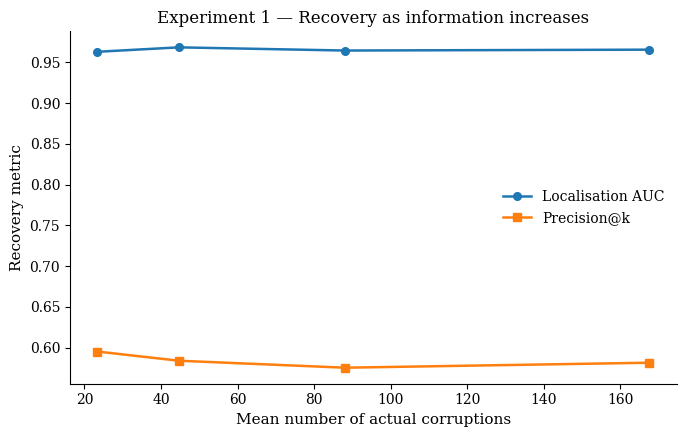

In [12]:
# Plot recovery as the amount of corruption information increases.
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    summary_exp1["corruptions_mean"],
    summary_exp1["localisation_auc_mean"],
    marker="o",
    label="Localisation AUC",
)

ax.plot(
    summary_exp1["corruptions_mean"],
    summary_exp1["precision_at_k_mean"],
    marker="s",
    label="Precision@k",
)

ax.set_xlabel("Mean number of actual corruptions")
ax.set_ylabel("Recovery metric")
ax.set_title("Experiment 1 — Recovery as information increases")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_exp1_information.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation

Experiment 1 asks how recovery changes as sample information increases while the
corruption mechanism remains fixed. Across the four sample sizes, mean localisation
AUC remains between 0.963 and 0.968, while mean Precision@$k$ remains between
0.575 and 0.595. Observation ranking is therefore already strong with only a few dozen
actual corruptions and changes little over the range studied.

Recovery of the response model improves more clearly with additional information:
mean coefficient RMSE falls from 0.118 at \(n=750\) to 0.053 at \(n=6000\).
Point estimation of the corruption mechanism also improves overall. Mean absolute
error in \(q\) falls from 0.080 to 0.055, while mean absolute error in \(c\) falls
from 0.109 to 0.079. However, interval coverage decreases as sample size increases:
coverage falls from 1.00 to 0.80 for \(c\) and from 0.95 to 0.75 for \(q\).
More observations therefore improve point estimation, but do not produce better
interval coverage for the corruption parameters.

## Experiment 2 — How strong must the corruption signal be?

Sample size and the true region are fixed while the one-sided corruption probability varies,

$$
q\in\{0.10,0.20,0.35,0.50,0.70\}.
$$

Again, the direction is supplied because the scientific question concerns the strength of the corruption signal, not uncertainty in $\alpha$.

Both $q$ and the actual effective flip rate are retained because the nominal corruption probability determines recovery through the number of informative label changes observed in the sample.

In [13]:
# Run Experiment 2 across corruption probabilities.
Q_VALUES = [0.10, 0.20, 0.35, 0.50, 0.70]
N_EXP2 = 3000
rows = []

for q_true in Q_VALUES:
    for rep in range(REPS):

        ckpt, cached = checkpoint_or_none(
            "exp2",
            q=q_true,
            rep=rep,
        )

        if cached is not None:
            print(
                f"Exp 2 | q={q_true:.2f} | rep={rep + 1}/{REPS} | "
                "checkpoint found"
            )
            rows.append(cached)
            continue

        seed = SEED + 20000 + int(q_true * 1000) + rep

        world = make_world(
            n=N_EXP2,
            alpha=ALPHA_AXIS,
            c=0.8,
            q=q_true,
            seed=seed,
        )

        print(
            f"Exp 2 | q={q_true:.2f} | rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        fit = fit_axis_world(
            world,
            seed + 1,
        )

        res = summarise_axis_fit(
            fit,
            world,
        )

        diag = core_diagnostics(
            fit
        )

        # Save q=.35 posterior scores for the confident-learning comparison.
        if np.isclose(q_true, 0.35):
            np.save(
                REPLICATE_DIR / f"exp2_q035_rep{rep:02d}_zmean.npy",
                np.asarray(res["z_mean"], dtype=np.float32),
            )

        row = {
            "q_true": q_true,
            "rep": rep,
            "seed": seed,
            **{
                k: v
                for k, v in res.items()
                if k != "z_mean"
            },
            **diag,
        }

        save_checkpoint(
            row,
            ckpt,
        )

        rows.append(row)

        del fit, res
        gc.collect()


results_exp2 = pd.DataFrame(
    rows
)


# Keep diagnostic pass rates from all fits.
pass_rate_exp2 = (
    results_exp2
    .groupby("q_true")["diagnostics_pass"]
    .mean()
    .rename("diagnostic_pass_rate")
)


# Use passing fits for recovery summaries.
valid_exp2 = results_exp2[
    results_exp2["diagnostics_pass"]
].copy()


summary_exp2 = (
    valid_exp2
    .groupby("q_true", as_index=False)
    .agg(
        effective_flip_rate_mean=("effective_flip_rate", "mean"),

        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),

        beta0_error_mean=("beta0_abs_error", "mean"),

        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        c_coverage=("c_covered", "mean"),

        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),
        q_coverage=("q_covered", "mean"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),

        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
    )
)


summary_exp2["diagnostic_pass_rate"] = (
    summary_exp2["q_true"]
    .map(pass_rate_exp2)
)

display(
    summary_exp2
)

18:07:55 - cmdstanpy - INFO - CmdStan start processing
18:07:55 - cmdstanpy - INFO - Chain [1] start processing
18:07:55 - cmdstanpy - INFO - Chain [2] start processing
18:07:55 - cmdstanpy - INFO - Chain [3] start processing
18:07:55 - cmdstanpy - INFO - Chain [4] start processing


Exp 2 | q=0.10 | rep=1/20 | corruptions=24


18:08:14 - cmdstanpy - INFO - Chain [2] done processing
18:08:17 - cmdstanpy - INFO - Chain [4] done processing
18:08:17 - cmdstanpy - INFO - Chain [1] done processing
18:08:20 - cmdstanpy - INFO - Chain [3] done processing
18:08:42 - cmdstanpy - INFO - CmdStan start processing
18:08:42 - cmdstanpy - INFO - Chain [1] start processing
18:08:42 - cmdstanpy - INFO - Chain [2] start processing
18:08:42 - cmdstanpy - INFO - Chain [3] start processing
18:08:42 - cmdstanpy - INFO - Chain [4] start processing


Exp 2 | q=0.10 | rep=2/20 | corruptions=25


18:09:02 - cmdstanpy - INFO - Chain [4] done processing
18:09:03 - cmdstanpy - INFO - Chain [2] done processing
18:09:03 - cmdstanpy - INFO - Chain [1] done processing
18:09:04 - cmdstanpy - INFO - Chain [3] done processing
18:09:26 - cmdstanpy - INFO - CmdStan start processing
18:09:26 - cmdstanpy - INFO - Chain [1] start processing
18:09:26 - cmdstanpy - INFO - Chain [2] start processing
18:09:26 - cmdstanpy - INFO - Chain [3] start processing
18:09:26 - cmdstanpy - INFO - Chain [4] start processing


...

Exp 2 | q=0.70 | rep=19/20 | corruptions=178


19:37:08 - cmdstanpy - INFO - Chain [1] done processing
19:37:09 - cmdstanpy - INFO - Chain [3] done processing
19:37:10 - cmdstanpy - INFO - Chain [2] done processing
19:37:11 - cmdstanpy - INFO - Chain [4] done processing
19:37:32 - cmdstanpy - INFO - CmdStan start processing
19:37:32 - cmdstanpy - INFO - Chain [1] start processing
19:37:32 - cmdstanpy - INFO - Chain [2] start processing
19:37:32 - cmdstanpy - INFO - Chain [3] start processing
19:37:32 - cmdstanpy - INFO - Chain [4] start processing


Exp 2 | q=0.70 | rep=20/20 | corruptions=164


19:37:52 - cmdstanpy - INFO - Chain [4] done processing
19:37:53 - cmdstanpy - INFO - Chain [3] done processing
19:37:53 - cmdstanpy - INFO - Chain [2] done processing
19:37:54 - cmdstanpy - INFO - Chain [1] done processing


,q_true,effective_flip_rate_mean,corruptions_mean,corruptions_sd,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,beta_coverage_mean,c_error_mean,c_error_sd,c_coverage,q_error_mean,q_error_sd,q_coverage,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,0.10,0.008083,24.25,3.958668,0.046962,0.060877,0.020903,0.94,0.286253,0.212579,1.00,0.042072,0.039754,0.95,0.954460,0.021868,0.391101,0.111876,1.0
1,0.20,0.015600,46.80,6.669648,0.051515,0.064590,0.014854,0.95,0.130160,0.092503,1.00,0.039195,0.030326,1.00,0.965230,0.006879,0.499414,0.055543,1.0
2,0.35,0.027933,83.80,6.925164,0.036750,0.059798,0.026084,0.96,0.085772,0.056821,0.95,0.049308,0.038659,0.95,0.965127,0.007319,0.569639,0.046115,1.0
3,0.50,0.041417,124.25,11.163262,0.048929,0.073315,0.023319,0.93,0.053659,0.035548,0.95,0.055976,0.037053,0.80,0.965826,0.004689,0.624288,0.038257,1.0
4,0.70,0.056850,170.55,13.782044,0.081446,0.083019,0.025531,0.87,0.033836,0.024147,0.95,0.047193,0.025034,0.85,0.965769,0.003764,0.669105,0.025968,1.0


In [14]:
# Easier-to-read view of the Experiment 2 summary.
display(
    summary_exp2[
        [
            "q_true",
            "corruptions_mean",
            "effective_flip_rate_mean",
            "beta_rmse_mean",
            "c_error_mean",
            "c_coverage",
            "q_error_mean",
            "q_coverage",
            "localisation_auc_mean",
            "precision_at_k_mean",
            "diagnostic_pass_rate",
        ]
    ].round(3)
)

,q_true,corruptions_mean,effective_flip_rate_mean,beta_rmse_mean,c_error_mean,c_coverage,q_error_mean,q_coverage,localisation_auc_mean,precision_at_k_mean,diagnostic_pass_rate
0,0.10,24.25,0.008,0.061,0.286,1.00,0.042,0.95,0.954,0.391,1.0
1,0.20,46.80,0.016,0.065,0.130,1.00,0.039,1.00,0.965,0.499,1.0
2,0.35,83.80,0.028,0.060,0.086,0.95,0.049,0.95,0.965,0.570,1.0
3,0.50,124.25,0.041,0.073,0.054,0.95,0.056,0.80,0.966,0.624,1.0
4,0.70,170.55,0.057,0.083,0.034,0.95,0.047,0.85,0.966,0.669,1.0


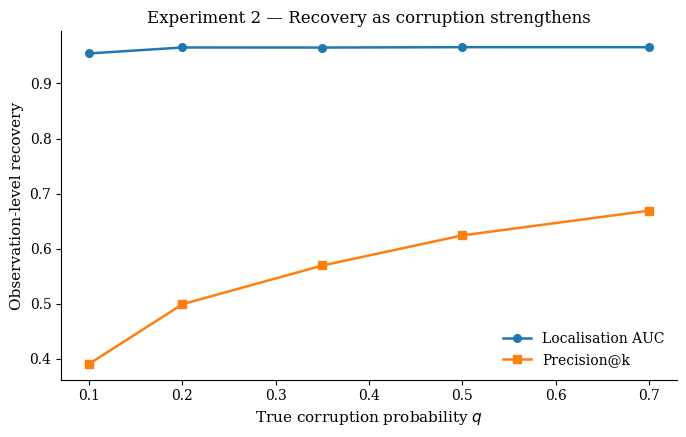

In [16]:
# Plot observation-level recovery as the corruption probability increases.
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    summary_exp2["q_true"],
    summary_exp2["localisation_auc_mean"],
    marker="o",
    label="Localisation AUC",
)

ax.plot(
    summary_exp2["q_true"],
    summary_exp2["precision_at_k_mean"],
    marker="s",
    label="Precision@k",
)

ax.set_xlabel("True corruption probability $q$")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 2 — Recovery as corruption strengthens")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_exp2_corruption_strength.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation

Experiment 2 varies the within-region corruption probability while holding the remaining
data-generating conditions fixed. Mean localisation AUC remains high throughout,
ranging from 0.954 to 0.966. Precision@$k$ improves more clearly as the corruption
signal strengthens, rising from 0.391 at \(q=0.10\) to 0.669 at \(q=0.70\).

Recovery of the latent response model remains fairly stable across the settings, with
mean coefficient RMSE between 0.060 and 0.083. Absolute error in \(c\) declines from
0.286 to 0.034 as the corruption signal strengthens, while absolute error in \(q\)
remains broadly stable. Relative error in \(q\) nevertheless decreases as the true
corruption probability increases.

The experiment therefore shows that localisation can remain strong under weak
corruption, while identifying individual corruptions and recovering the corruption
mechanism benefit from a stronger signal.

## Experiment 3 — How much population mass must lie inside the region?

Here $n$ and $q$ are fixed while the threshold $c$ moves. Since $\alpha$ is unit length and the covariates are standard normal, changing $c$ changes the population share within the true halfspace.

This directly studies the amount of susceptible-population information available to the estimator. The quantities to retain are the region share, eligible positives and actual corruption events.

In [17]:
# Run Experiment 3a across boundary thresholds.
C_VALUES = [0.0, 0.5, 0.8, 1.28, 1.65]
N_EXP3 = 3000
Q_EXP3 = 0.35
rows = []

for c_true in C_VALUES:
    for rep in range(REPS):

        ckpt, cached = checkpoint_or_none(
            "exp3a",
            c=c_true,
            rep=rep,
        )

        if cached is not None:
            print(
                f"Exp 3a | c={c_true:.2f} | rep={rep + 1}/{REPS} | "
                "checkpoint found"
            )
            rows.append(cached)
            continue

        seed = SEED + 30000 + int((c_true + 2) * 1000) + rep

        world = make_world(
            n=N_EXP3,
            alpha=ALPHA_AXIS,
            c=c_true,
            q=Q_EXP3,
            seed=seed,
        )

        print(
            f"Exp 3a | c={c_true:.2f} | "
            f"region={world['region'].mean():.1%} | "
            f"rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        fit = fit_axis_world(
            world,
            seed + 1,
        )

        res = summarise_axis_fit(
            fit,
            world,
        )

        diag = core_diagnostics(
            fit
        )

        row = {
            "c_true": c_true,
            "rep": rep,
            "seed": seed,
            **{
                k: v
                for k, v in res.items()
                if k != "z_mean"
            },
            **diag,
        }

        save_checkpoint(
            row,
            ckpt,
        )

        rows.append(row)

        del fit, res
        gc.collect()


results_exp3 = pd.DataFrame(
    rows
)


# Keep diagnostic pass rates from all fits.
pass_rate_exp3 = (
    results_exp3
    .groupby("c_true")["diagnostics_pass"]
    .mean()
    .rename("diagnostic_pass_rate")
)


# Use passing fits for recovery summaries.
valid_exp3 = results_exp3[
    results_exp3["diagnostics_pass"]
].copy()


summary_exp3 = (
    valid_exp3
    .groupby("c_true", as_index=False)
    .agg(
        region_share_mean=("region_share", "mean"),
        region_share_sd=("region_share", "std"),

        eligible_mean=("eligible_positives", "mean"),

        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),

        beta0_error_mean=("beta0_abs_error", "mean"),

        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        c_coverage=("c_covered", "mean"),

        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),
        q_coverage=("q_covered", "mean"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),

        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
    )
)


summary_exp3["diagnostic_pass_rate"] = (
    summary_exp3["c_true"]
    .map(pass_rate_exp3)
)

display(
    summary_exp3
)

19:47:08 - cmdstanpy - INFO - CmdStan start processing
19:47:08 - cmdstanpy - INFO - Chain [1] start processing
19:47:08 - cmdstanpy - INFO - Chain [2] start processing
19:47:08 - cmdstanpy - INFO - Chain [3] start processing
19:47:08 - cmdstanpy - INFO - Chain [4] start processing


Exp 3a | c=0.00 | region=51.0% | rep=1/20 | corruptions=206


19:47:26 - cmdstanpy - INFO - Chain [1] done processing
19:47:28 - cmdstanpy - INFO - Chain [2] done processing
19:47:30 - cmdstanpy - INFO - Chain [4] done processing
19:47:31 - cmdstanpy - INFO - Chain [3] done processing
19:47:53 - cmdstanpy - INFO - CmdStan start processing
19:47:53 - cmdstanpy - INFO - Chain [1] start processing
19:47:53 - cmdstanpy - INFO - Chain [2] start processing
19:47:53 - cmdstanpy - INFO - Chain [3] start processing
19:47:53 - cmdstanpy - INFO - Chain [4] start processing


Exp 3a | c=0.00 | region=49.3% | rep=2/20 | corruptions=203


19:48:12 - cmdstanpy - INFO - Chain [3] done processing
19:48:13 - cmdstanpy - INFO - Chain [4] done processing
19:48:13 - cmdstanpy - INFO - Chain [2] done processing
19:48:13 - cmdstanpy - INFO - Chain [1] done processing
19:48:35 - cmdstanpy - INFO - CmdStan start processing
19:48:35 - cmdstanpy - INFO - Chain [1] start processing
19:48:35 - cmdstanpy - INFO - Chain [2] start processing
19:48:35 - cmdstanpy - INFO - Chain [3] start processing
19:48:35 - cmdstanpy - INFO - Chain [4] start processing


...

Exp 3a | c=1.65 | region=4.4% | rep=19/20 | corruptions=15


21:04:24 - cmdstanpy - INFO - Chain [1] done processing
21:04:25 - cmdstanpy - INFO - Chain [2] done processing
21:04:26 - cmdstanpy - INFO - Chain [3] done processing
21:04:27 - cmdstanpy - INFO - Chain [4] done processing
21:04:49 - cmdstanpy - INFO - CmdStan start processing
21:04:49 - cmdstanpy - INFO - Chain [1] start processing
21:04:49 - cmdstanpy - INFO - Chain [2] start processing
21:04:49 - cmdstanpy - INFO - Chain [3] start processing
21:04:49 - cmdstanpy - INFO - Chain [4] start processing


Exp 3a | c=1.65 | region=4.7% | rep=20/20 | corruptions=18


21:05:13 - cmdstanpy - INFO - Chain [4] done processing
21:05:14 - cmdstanpy - INFO - Chain [3] done processing
21:05:15 - cmdstanpy - INFO - Chain [2] done processing
21:05:16 - cmdstanpy - INFO - Chain [1] done processing


,c_true,region_share_mean,region_share_sd,eligible_mean,corruptions_mean,corruptions_sd,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,beta_coverage_mean,...,c_error_sd,c_coverage,q_error_mean,q_error_sd,q_coverage,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,0.00,0.498383,0.006169,568.70,194.10,13.749258,0.048814,0.064796,0.029148,0.95,...,0.031976,1.00,0.033671,0.028148,0.90,0.925393,0.006507,0.583912,0.030894,1.0
1,0.50,0.311033,0.007808,356.45,123.85,7.645260,0.050500,0.069630,0.021467,0.97,...,0.046668,0.95,0.057917,0.040255,0.75,0.948981,0.007390,0.565050,0.039751,1.0
2,0.80,0.212017,0.006177,245.00,83.35,9.292187,0.054900,0.064794,0.026371,0.95,...,0.051742,0.95,0.052461,0.040618,0.90,0.966311,0.006625,0.578556,0.055396,1.0
3,1.28,0.100217,0.004284,117.10,40.65,6.737757,0.054954,0.062686,0.021150,0.93,...,0.061552,1.00,0.057328,0.046046,0.90,0.982483,0.004731,0.561884,0.062049,1.0
4,1.65,0.049067,0.003331,56.00,18.90,4.459172,0.048449,0.055110,0.016413,0.96,...,0.136896,1.00,0.065233,0.053521,1.00,0.988525,0.007094,0.541255,0.100587,1.0


In [18]:
# Easier-to-read view of the Experiment 3 summary.
display(
    summary_exp3[
        [
            "c_true",
            "region_share_mean",
            "eligible_mean",
            "corruptions_mean",
            "beta_rmse_mean",
            "c_error_mean",
            "c_coverage",
            "q_error_mean",
            "q_coverage",
            "localisation_auc_mean",
            "precision_at_k_mean",
            "diagnostic_pass_rate",
        ]
    ].round(3)
)

,c_true,region_share_mean,eligible_mean,corruptions_mean,beta_rmse_mean,c_error_mean,c_coverage,q_error_mean,q_coverage,localisation_auc_mean,precision_at_k_mean,diagnostic_pass_rate
0,0.00,0.498,568.70,194.10,0.065,0.046,1.00,0.034,0.90,0.925,0.584,1.0
1,0.50,0.311,356.45,123.85,0.070,0.062,0.95,0.058,0.75,0.949,0.565,1.0
2,0.80,0.212,245.00,83.35,0.065,0.076,0.95,0.052,0.90,0.966,0.579,1.0
3,1.28,0.100,117.10,40.65,0.063,0.094,1.00,0.057,0.90,0.982,0.562,1.0
4,1.65,0.049,56.00,18.90,0.055,0.127,1.00,0.065,1.00,0.989,0.541,1.0


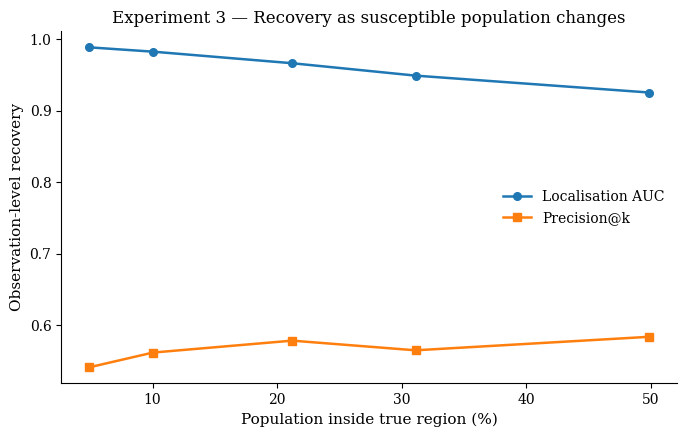

In [19]:
# Plot observation-level recovery against the susceptible population share.
plot_exp3 = summary_exp3.sort_values("region_share_mean").copy()

fig, ax = plt.subplots(figsize=(7, 4.5))

x = 100 * plot_exp3["region_share_mean"]

ax.plot(
    x,
    plot_exp3["localisation_auc_mean"],
    marker="o",
    label="Localisation AUC",
)

ax.plot(
    x,
    plot_exp3["precision_at_k_mean"],
    marker="s",
    label="Precision@k",
)

ax.set_xlabel("Population inside true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 3 — Recovery as susceptible population changes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp3a_susceptible_population.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation

Experiment 3a varies the threshold \(c\), changing both the susceptible population mass
and the boundary's position in the covariate distribution. As the threshold increases,
the mean region share falls from approximately 50\% to 5\%, and the mean number of
actual corruptions falls from 194.1 to 18.9.

Mean localisation AUC nevertheless rises from 0.925 to 0.989, while
Precision@\(k\) shows no clear trend. This should not be read as evidence that rare
susceptible subgroups are generally easier to recover, since moving \(c\) changes both
region size and location. A small, concentrated region can be easy to rank against the
remainder of the population even when relatively few corruption events are observed.

Experiment 3b therefore separates these effects by varying population mass while holding
the corruption boundary fixed.

## Experiment 3b — Population mass with fixed geometry

Experiment 3a changes the threshold $c$, which changes both the location of the corruption region and the amount of population inside it. This follow-up keeps the boundary itself fixed at

$$
R=\{x_5>0.8\}
$$

and instead shifts the marginal distribution of the null boundary covariate $x_5$.

Because $x_5$ has coefficient zero in the latent response model, changing its mean alters how much population falls inside the corruption region without changing the latent response relationship. This isolates the effect of population mass on estimation.

In [20]:
# Run Experiment 3b across shifts in the boundary covariate.
MU5_VALUES = [-1.0, -0.5, 0.0, 0.5]
N_EXP3B = 3000
C_EXP3B = 0.8
Q_EXP3B = 0.35
rows = []

for mu5 in MU5_VALUES:
    for rep in range(REPS):

        ckpt, cached = checkpoint_or_none(
            "exp3b",
            mu5=mu5,
            rep=rep,
        )

        if cached is not None:
            print(
                f"Exp 3b | mu5={mu5:+.2f} | rep={rep + 1}/{REPS} | "
                "checkpoint found"
            )
            rows.append(cached)
            continue

        seed = SEED + 35000 + int((mu5 + 2) * 1000) + rep

        mean_shift = np.zeros(
            len(BETA_TRUE),
            dtype=np.float64,
        )
        mean_shift[4] = mu5

        world = make_world(
            n=N_EXP3B,
            alpha=ALPHA_AXIS,
            c=C_EXP3B,
            q=Q_EXP3B,
            seed=seed,
            mean_shift=mean_shift,
        )

        print(
            f"Exp 3b | mu5={mu5:+.2f} | "
            f"region={world['region'].mean():.1%} | "
            f"rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        fit = fit_axis_world(
            world,
            seed + 1,
        )

        res = summarise_axis_fit(
            fit,
            world,
        )

        diag = core_diagnostics(
            fit
        )

        row = {
            "mu5": mu5,
            "rep": rep,
            "seed": seed,
            **{
                k: v
                for k, v in res.items()
                if k != "z_mean"
            },
            **diag,
        }

        save_checkpoint(
            row,
            ckpt,
        )

        rows.append(row)

        del fit, res
        gc.collect()


results_exp3b = pd.DataFrame(
    rows
)


# Keep diagnostic pass rates from all fits.
pass_rate_exp3b = (
    results_exp3b
    .groupby("mu5")["diagnostics_pass"]
    .mean()
    .rename("diagnostic_pass_rate")
)


# Use passing fits for recovery summaries.
valid_exp3b = results_exp3b[
    results_exp3b["diagnostics_pass"]
].copy()


summary_exp3b = (
    valid_exp3b
    .groupby("mu5", as_index=False)
    .agg(
        region_share_mean=("region_share", "mean"),
        region_share_sd=("region_share", "std"),

        eligible_mean=("eligible_positives", "mean"),

        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),

        beta0_error_mean=("beta0_abs_error", "mean"),

        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        c_coverage=("c_covered", "mean"),

        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),
        q_coverage=("q_covered", "mean"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),

        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
    )
)


summary_exp3b["diagnostic_pass_rate"] = (
    summary_exp3b["mu5"]
    .map(pass_rate_exp3b)
)

display(
    summary_exp3b
)

21:10:30 - cmdstanpy - INFO - CmdStan start processing
21:10:30 - cmdstanpy - INFO - Chain [1] start processing
21:10:30 - cmdstanpy - INFO - Chain [2] start processing
21:10:30 - cmdstanpy - INFO - Chain [3] start processing
21:10:30 - cmdstanpy - INFO - Chain [4] start processing


Exp 3b | mu5=-1.00 | region=3.6% | rep=1/20 | corruptions=15


21:10:55 - cmdstanpy - INFO - Chain [2] done processing
21:10:56 - cmdstanpy - INFO - Chain [1] done processing
21:10:56 - cmdstanpy - INFO - Chain [4] done processing
21:10:57 - cmdstanpy - INFO - Chain [3] done processing
21:11:19 - cmdstanpy - INFO - CmdStan start processing
21:11:19 - cmdstanpy - INFO - Chain [1] start processing
21:11:19 - cmdstanpy - INFO - Chain [2] start processing
21:11:19 - cmdstanpy - INFO - Chain [3] start processing
21:11:19 - cmdstanpy - INFO - Chain [4] start processing


Exp 3b | mu5=-1.00 | region=4.0% | rep=2/20 | corruptions=16


21:11:43 - cmdstanpy - INFO - Chain [3] done processing
21:11:44 - cmdstanpy - INFO - Chain [1] done processing
21:11:46 - cmdstanpy - INFO - Chain [4] done processing
21:11:46 - cmdstanpy - INFO - Chain [2] done processing
21:12:07 - cmdstanpy - INFO - CmdStan start processing
21:12:07 - cmdstanpy - INFO - Chain [1] start processing
21:12:07 - cmdstanpy - INFO - Chain [2] start processing
21:12:07 - cmdstanpy - INFO - Chain [3] start processing
21:12:07 - cmdstanpy - INFO - Chain [4] start processing


...

Exp 3b | mu5=+0.50 | region=38.3% | rep=19/20 | corruptions=176


22:12:21 - cmdstanpy - INFO - Chain [3] done processing
22:12:24 - cmdstanpy - INFO - Chain [4] done processing
22:12:25 - cmdstanpy - INFO - Chain [2] done processing
22:12:26 - cmdstanpy - INFO - Chain [1] done processing
22:12:47 - cmdstanpy - INFO - CmdStan start processing
22:12:47 - cmdstanpy - INFO - Chain [1] start processing
22:12:47 - cmdstanpy - INFO - Chain [2] start processing
22:12:47 - cmdstanpy - INFO - Chain [3] start processing
22:12:47 - cmdstanpy - INFO - Chain [4] start processing


Exp 3b | mu5=+0.50 | region=37.6% | rep=20/20 | corruptions=156


22:13:07 - cmdstanpy - INFO - Chain [1] done processing
22:13:07 - cmdstanpy - INFO - Chain [2] done processing
22:13:10 - cmdstanpy - INFO - Chain [3] done processing
22:13:12 - cmdstanpy - INFO - Chain [4] done processing


,mu5,region_share_mean,region_share_sd,eligible_mean,corruptions_mean,corruptions_sd,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,beta_coverage_mean,...,c_error_sd,c_coverage,q_error_mean,q_error_sd,q_coverage,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,-1.0,0.035200,0.003520,40.25,15.25,2.971354,0.045854,0.056061,0.017075,0.94,...,0.090065,1.00,0.077756,0.056656,1.00,0.992406,0.003631,0.578286,0.092729,1.0
1,-0.5,0.097333,0.006325,112.60,39.15,6.899847,0.071223,0.058722,0.018865,0.96,...,0.082965,0.95,0.070531,0.045137,1.00,0.981460,0.004768,0.559769,0.061090,1.0
2,0.0,0.210767,0.008210,243.55,83.80,5.559250,0.044855,0.063230,0.022556,0.95,...,0.055928,0.95,0.052577,0.037849,0.90,0.967115,0.004384,0.579114,0.031570,1.0
3,0.5,0.382600,0.009021,445.50,159.90,14.048413,0.063556,0.084882,0.029289,0.89,...,0.047885,1.00,0.052686,0.043714,0.75,0.941397,0.008128,0.587805,0.034474,1.0


In [21]:
# Easier-to-read view of the Experiment 3b summary.
display(
    summary_exp3b[
        [
            "mu5",
            "region_share_mean",
            "eligible_mean",
            "corruptions_mean",
            "beta_rmse_mean",
            "c_error_mean",
            "c_coverage",
            "q_error_mean",
            "q_coverage",
            "localisation_auc_mean",
            "precision_at_k_mean",
            "diagnostic_pass_rate",
        ]
    ].round(3)
)

,mu5,region_share_mean,eligible_mean,corruptions_mean,beta_rmse_mean,c_error_mean,c_coverage,q_error_mean,q_coverage,localisation_auc_mean,precision_at_k_mean,diagnostic_pass_rate
0,-1.0,0.035,40.25,15.25,0.056,0.132,1.00,0.078,1.00,0.992,0.578,1.0
1,-0.5,0.097,112.60,39.15,0.059,0.102,0.95,0.071,1.00,0.981,0.560,1.0
2,0.0,0.211,243.55,83.80,0.063,0.069,0.95,0.053,0.90,0.967,0.579,1.0
3,0.5,0.383,445.50,159.90,0.085,0.059,1.00,0.053,0.75,0.941,0.588,1.0


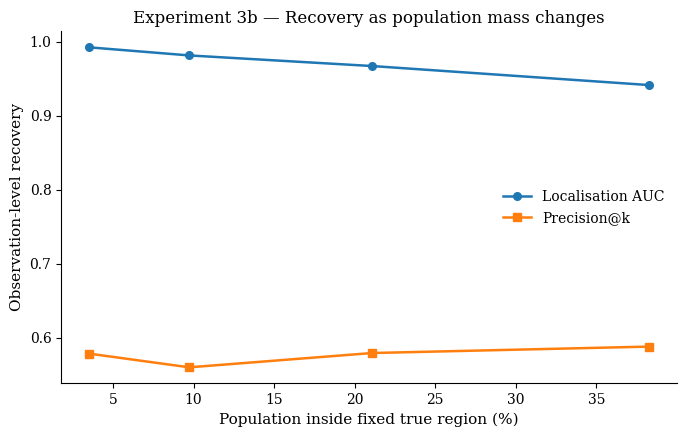

In [22]:
# Plot observation-level recovery against population mass in the fixed region.
plot_exp3b = summary_exp3b.sort_values("region_share_mean").copy()

fig, ax = plt.subplots(figsize=(7, 4.5))

x = 100 * plot_exp3b["region_share_mean"]

ax.plot(
    x,
    plot_exp3b["localisation_auc_mean"],
    marker="o",
    label="Localisation AUC",
)

ax.plot(
    x,
    plot_exp3b["precision_at_k_mean"],
    marker="s",
    label="Precision@k",
)

ax.set_xlabel("Population inside fixed true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 3b — Recovery as population mass changes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp3b_population_mass.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation

Experiment 3b fixes the corruption boundary and changes only the population mass inside
it. As the mean region share rises from 3.5\% to 38.3\%, the mean number of actual
corruptions increases from 15.3 to 159.9.

Mean localisation AUC declines from 0.992 to 0.941 as the susceptible population becomes
less concentrated, while Precision@$k$ remains comparatively stable. Recovery of the
latent response coefficients is also broadly stable. In contrast, mean absolute error
in \(c\) falls from 0.132 to 0.059 and mean absolute error in \(q\) falls from
0.078 to 0.053 as the susceptible population increases.

Together with Experiment 3a, this shows that population concentration affects observation
ranking, while greater susceptible-population mass provides more information for
recovering the corruption mechanism.

## Experiment 4a — When the direction itself must be learned

Experiment 4a uses the full general-$\alpha$ model.

To isolate boundary geometry from the latent response signal, this experiment uses six covariates with

$$
\beta=(1.5,-1.2,0.8,-0.6,0,0).
$$

The two corruption boundaries therefore lie entirely in dimensions that are null for the response model:

$$
\alpha_{\mathrm{axis}}=(0,0,0,0,0,1),
$$

and

$$
\alpha_{\mathrm{oblique}}
=
\frac{1}{\sqrt{2}}(0,0,0,0,1,1).
$$

The probabilistic model is unchanged; only the simulated boundary geometry changes. Fits are evaluated at $n=1500$ and $n=6000$ to ask what happens when the boundary direction must be estimated rather than supplied.

Ten independently simulated datasets are used for each geometry--sample-size condition. Recovery of $\alpha$, $c$, $q$, the response parameters and observation-level corruption probabilities is assessed together with the stability of posterior inference across chains.

Throughout the notebook, a fit is treated as diagnostically acceptable when there are no divergent transitions or maximum-tree-depth hits, $\widehat R\leq1.05$, and bulk ESS $\geq100$ for the core sampled parameters. In Experiment 4a the diagnostics are also a substantive outcome, because cross-chain disagreement may reveal competing explanations of the response and corruption mechanisms.

In [23]:
# Experiment 4a: learn the boundary direction under axis-aligned and oblique geometry.
# The final two covariates are null in the latent response model.

BETA_GEOM = np.array(
    [1.5, -1.2, 0.8, -0.6, 0.0, 0.0],
    dtype=np.float64,
)

ALPHA_AXIS_GEOM = np.array(
    [0, 0, 0, 0, 0, 1.0],
    dtype=np.float64,
)

ALPHA_OBLIQUE_GEOM = np.array(
    [0, 0, 0, 0, 1.0, 1.0],
    dtype=np.float64,
)
ALPHA_OBLIQUE_GEOM /= np.linalg.norm(ALPHA_OBLIQUE_GEOM)

GEOMETRIES = {
    "axis": ALPHA_AXIS_GEOM,
    "oblique": ALPHA_OBLIQUE_GEOM,
}

N_GEOM = [1500, 6000]
GEOM_REPS = 10

rows = []

for geometry, alpha_true in GEOMETRIES.items():
    for n in N_GEOM:
        for rep in range(GEOM_REPS):

            ckpt, cached = checkpoint_or_none(
                "exp4a",
                geometry=geometry,
                n=n,
                rep=rep,
            )

            if cached is not None:
                print(
                    f"Exp 4a | {geometry} | n={n} | "
                    f"rep={rep + 1}/{GEOM_REPS} | checkpoint found"
                )
                rows.append(cached)
                continue

            seed = (
                SEED
                + 40000
                + (10000 if geometry == "oblique" else 0)
                + n
                + rep
            )

            world = make_world(
                n=n,
                alpha=alpha_true,
                c=0.8,
                q=0.35,
                seed=seed,
                beta=BETA_GEOM,
            )

            print(
                f"Exp 4a | {geometry} | n={n} | "
                f"rep={rep + 1}/{GEOM_REPS} | "
                f"corruptions={world['flips'].sum()}"
            )

            fit = fit_general_world(
                world,
                seed + 1,
            )

            general_fits[
                ("exp4", geometry, n, rep)
            ] = fit

            res = summarise_general_fit(
                fit,
                world,
            )

            diag = core_diagnostics(
                fit
            )

            row = {
                "geometry": geometry,
                "n": n,
                "rep": rep,
                "seed": seed,
                **{
                    k: v
                    for k, v in res.items()
                    if k != "z_mean"
                },
                **diag,
            }

            save_checkpoint(
                row,
                ckpt,
            )

            rows.append(row)

            del res
            gc.collect()


results_exp4 = pd.DataFrame(
    rows
)


# Show the replicate-level results and diagnostics.
display(
    results_exp4[
        [
            "geometry",
            "n",
            "rep",
            "n_corrupted",
            "alpha_cosine_mean",
            "alpha_cosine_p05",
            "beta_rmse",
            "c_abs_error",
            "q_abs_error",
            "localisation_auc",
            "precision_at_k",
            "max_rhat",
            "min_ess_bulk",
            "divergences",
            "max_treedepth_hits",
            "diagnostics_pass",
        ]
    ]
)


# Diagnostic performance is reported separately for each condition.
diagnostics_exp4 = (
    results_exp4
    .groupby(
        ["geometry", "n"],
        as_index=False,
    )
    .agg(
        fits=("diagnostics_pass", "size"),
        passing_fits=("diagnostics_pass", "sum"),
        pass_rate=("diagnostics_pass", "mean"),
        worst_rhat=("max_rhat", "max"),
        lowest_ess=("min_ess_bulk", "min"),
        total_divergences=("divergences", "sum"),
        total_treedepth_hits=("max_treedepth_hits", "sum"),
    )
)

display(
    diagnostics_exp4
)


# Recovery summaries use only fits that pass the diagnostic gate.
valid_exp4 = results_exp4[
    results_exp4["diagnostics_pass"]
].copy()

if len(valid_exp4) == 0:
    raise RuntimeError(
        "No Experiment 4a fits passed the diagnostic criteria."
    )


summary_exp4 = (
    valid_exp4
    .groupby(
        ["geometry", "n"],
        as_index=False,
    )
    .agg(
        n_valid=("rep", "size"),

        corruptions_mean=("n_corrupted", "mean"),

        beta0_error_mean=("beta0_abs_error", "mean"),
        beta_rmse_mean=("beta_rmse", "mean"),
        beta_coverage_mean=("beta_coverage", "mean"),

        cosine_mean=("alpha_cosine_mean", "mean"),
        cosine_sd=("alpha_cosine_mean", "std"),
        cosine_p05_mean=("alpha_cosine_p05", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        q_error_mean=("q_abs_error", "mean"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),

        precision_at_k_mean=("precision_at_k", "mean"),
    )
)

display(
    summary_exp4
)

Exp 4a | axis | n=1500 | rep=1/10 | corruptions=53


22:21:59 - cmdstanpy - INFO - CmdStan start processing
22:21:59 - cmdstanpy - INFO - Chain [1] start processing
22:21:59 - cmdstanpy - INFO - Chain [2] start processing
22:21:59 - cmdstanpy - INFO - Chain [3] start processing
22:21:59 - cmdstanpy - INFO - Chain [4] start processing
22:22:16 - cmdstanpy - INFO - Chain [3] done processing
22:22:17 - cmdstanpy - INFO - Chain [2] done processing
22:22:17 - cmdstanpy - INFO - Chain [1] done processing
22:22:20 - cmdstanpy - INFO - Chain [4] done processing
22:22:31 - cmdstanpy - INFO - CmdStan start processing
22:22:31 - cmdstanpy - INFO - Chain [1] start processing
22:22:31 - cmdstanpy - INFO - Chain [2] start processing
22:22:31 - cmdstanpy - INFO - Chain [3] start processing
22:22:31 - cmdstanpy - INFO - Chain [4] start processing


Exp 4a | axis | n=1500 | rep=2/10 | corruptions=48


22:22:48 - cmdstanpy - INFO - Chain [4] done processing
22:22:51 - cmdstanpy - INFO - Chain [1] done processing
22:22:51 - cmdstanpy - INFO - Chain [2] done processing
22:22:51 - cmdstanpy - INFO - Chain [3] done processing
22:23:03 - cmdstanpy - INFO - CmdStan start processing
22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [2] start processing
22:23:03 - cmdstanpy - INFO - Chain [3] start processing
22:23:03 - cmdstanpy - INFO - Chain [4] start processing


Exp 4a | axis | n=1500 | rep=3/10 | corruptions=41


...

Exp 4a | oblique | n=6000 | rep=10/10 | corruptions=165


23:29:23 - cmdstanpy - INFO - Chain [1] done processing
23:29:36 - cmdstanpy - INFO - Chain [3] done processing
23:29:48 - cmdstanpy - INFO - Chain [4] done processing
23:30:10 - cmdstanpy - INFO - Chain [2] done processing


,geometry,n,rep,n_corrupted,alpha_cosine_mean,alpha_cosine_p05,beta_rmse,c_abs_error,q_abs_error,localisation_auc,precision_at_k,max_rhat,min_ess_bulk,divergences,max_treedepth_hits,diagnostics_pass
0,axis,1500,0,53,0.918398,0.810780,0.107835,0.026141,0.074735,0.950655,0.452830,1.00331,1304.85000,0,0,True
1,axis,1500,1,48,0.921398,0.798272,0.162400,0.070156,0.077469,0.973641,0.625000,1.00808,948.93600,0,0,True
2,axis,1500,2,41,0.869376,0.660372,0.060641,0.030203,0.023214,0.969046,0.536585,1.00235,1567.68000,0,0,True
3,axis,1500,3,45,0.908623,0.803633,0.104280,0.417611,0.013262,0.931276,0.511111,1.00289,1413.30000,0,0,True
4,axis,1500,4,45,0.827159,0.458749,0.069535,0.261263,0.055467,0.931906,0.622222,1.00535,665.00200,0,0,True
5,axis,1500,5,47,0.916520,0.799880,0.097655,0.051454,0.057804,0.955736,0.574468,1.00374,673.88100,0,0,True
6,axis,1500,6,29,0.571261,-0.184952,0.079233,0.196461,0.093720,0.957797,0.517241,1.01198,463.87100,0,0,True
7,axis,1500,7,44,0.947543,0.886232,0.078968,0.092514,0.065539,0.971021,0.659091,1.00244,1849.68000,0,0,True
8,axis,1500,8,45,0.936517,0.847137,0.032527,0.009177,0.118680,0.951634,0.622222,1.00182,1569.77000,0,0,True
9,axis,1500,9,47,0.720926,0.147988,0.078351,0.251648,0.037459,0.944653,0.489362,1.00582,648.67700,0,0,True


,geometry,n,fits,passing_fits,pass_rate,worst_rhat,lowest_ess,total_divergences,total_treedepth_hits
0,axis,1500,10,10,1.0,1.01198,463.87100,0,0
1,axis,6000,10,4,0.4,1.73575,6.09344,1,0
2,oblique,1500,10,10,1.0,1.00722,548.24800,0,0
3,oblique,6000,10,4,0.4,1.73677,6.10022,0,0


,geometry,n,n_valid,corruptions_mean,beta0_error_mean,beta_rmse_mean,beta_coverage_mean,cosine_mean,cosine_sd,cosine_p05_mean,c_error_mean,q_error_mean,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean
0,axis,1500,10,44.40,0.113305,0.087143,0.983333,0.853772,0.120068,0.602809,0.140663,0.061735,0.953737,0.015008,0.561013
1,axis,6000,4,170.25,0.050397,0.041753,0.916667,0.976420,0.011963,0.946207,0.118977,0.011840,0.962923,0.004328,0.592513
2,oblique,1500,10,41.10,0.116963,0.098158,0.950000,0.761450,0.155386,0.457979,0.336317,0.064658,0.937837,0.029592,0.525929
3,oblique,6000,4,162.75,0.086014,0.049314,0.958333,0.978531,0.010737,0.954804,0.091356,0.056777,0.962488,0.002344,0.564136


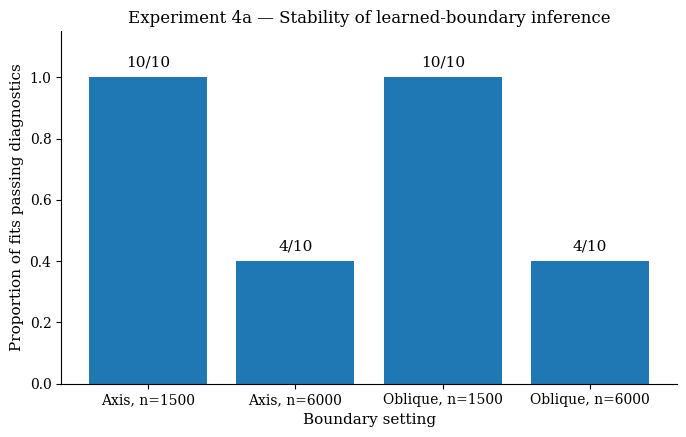

In [24]:
# Plot the diagnostic pass rate for each learned-boundary condition.
plot_diag = diagnostics_exp4.copy()

labels = (
    plot_diag["geometry"].str.capitalize()
    + ", n="
    + plot_diag["n"].astype(str)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    labels,
    plot_diag["pass_rate"],
)

ax.set_ylim(0, 1.15)
ax.set_ylabel("Proportion of fits passing diagnostics")
ax.set_xlabel("Boundary setting")
ax.set_title("Experiment 4a — Stability of learned-boundary inference")

for bar, rate, n_ok, n_total in zip(
    bars,
    plot_diag["pass_rate"],
    plot_diag["passing_fits"],
    plot_diag["fits"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        float(rate) + 0.025,
        f"{int(n_ok)}/{int(n_total)}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp4_boundary_recoverability.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Experiment 4a interpretation

Experiment 4a considers the harder setting in which the corruption-boundary direction
$\alpha$ must be learned rather than supplied.

At $n=1500$, all 10 axis-aligned fits and all 10 oblique fits pass the diagnostic
gate. At $n=6000$, only 4 of 10 fits pass for each geometry. Most failures show
cross-chain disagreement, with $\widehat R$ values around 1.53--1.74 and bulk
effective sample sizes of about 6--7. One axis-aligned fit fails because of a single
divergent transition despite otherwise consistent chains.

Among fits that pass the diagnostic gate, orientation recovery improves with sample
size. Mean cosine similarity increases from $0.854\pm0.120$ to
$0.976\pm0.012$ for the axis-aligned boundary and from $0.761\pm0.155$ to
$0.979\pm0.011$ for the oblique boundary. Localisation AUC remains high across
the valid fits.

Larger samples can therefore support highly accurate orientation recovery when the
posterior is explored consistently, but they do not eliminate instability across
datasets. The failed fits indicate competing posterior explanations rather than
uniformly poor recovery.

Experiment 4b asks whether a larger sample resolves this instability in the oblique
setting.

## Experiment 4b — Does larger $n$ resolve the learned-boundary ambiguity?

Experiment 4a shows that some simulated datasets recover the learned boundary well,
while others produce unstable posterior inference. Experiment 4b asks whether increasing
the sample size resolves this instability.

The oblique geometry is held fixed and the sample size is increased to $n=12000$.
The probabilistic model, corruption mechanism and response model are unchanged.
Ten independently simulated datasets are fitted using the same general-$\alpha$ model
and diagnostic gate as in Experiment 4a.

This is a targeted large-sample check rather than a new factorial experiment. It tests
whether the learned-boundary instability observed at $n=6000$ persists with substantially
more data.

In [25]:
# Experiment 4b: test the oblique learned boundary at a larger sample size.

N_ASYMPTOTIC = 12000
ASYMPTOTIC_REPS = 10

asym_rows = []

for rep in range(ASYMPTOTIC_REPS):

    ckpt, cached = checkpoint_or_none(
        "exp4b",
        geometry="oblique",
        n=N_ASYMPTOTIC,
        rep=rep,
    )

    if cached is not None:
        print(
            f"Exp 4b | oblique | n={N_ASYMPTOTIC} | "
            f"rep={rep + 1}/{ASYMPTOTIC_REPS} | checkpoint found"
        )
        asym_rows.append(cached)
        continue

    seed = SEED + 80000 + N_ASYMPTOTIC + rep

    world = make_world(
        n=N_ASYMPTOTIC,
        alpha=ALPHA_OBLIQUE_GEOM,
        c=0.8,
        q=0.35,
        seed=seed,
        beta=BETA_GEOM,
    )

    print(
        f"Exp 4b | oblique | n={N_ASYMPTOTIC} | "
        f"rep={rep + 1}/{ASYMPTOTIC_REPS} | "
        f"corruptions={world['flips'].sum()}"
    )

    fit = fit_general_world(
        world,
        seed + 1,
    )

    general_fits[
        ("exp4b", "oblique", N_ASYMPTOTIC, rep)
    ] = fit

    res = summarise_general_fit(
        fit,
        world,
    )

    diag = core_diagnostics(
        fit
    )

    row = {
        "geometry": "oblique",
        "n": N_ASYMPTOTIC,
        "rep": rep,
        "seed": seed,
        **{
            k: v
            for k, v in res.items()
            if k != "z_mean"
        },
        **diag,
    }

    save_checkpoint(
        row,
        ckpt,
    )

    asym_rows.append(row)

    del res
    gc.collect()


results_exp4b = pd.DataFrame(
    asym_rows
)


# Show the replicate-level results and diagnostics.
display(
    results_exp4b[
        [
            "geometry",
            "n",
            "rep",
            "n_corrupted",
            "alpha_cosine_mean",
            "alpha_cosine_p05",
            "beta_rmse",
            "c_abs_error",
            "q_abs_error",
            "localisation_auc",
            "precision_at_k",
            "max_rhat",
            "min_ess_bulk",
            "divergences",
            "max_treedepth_hits",
            "diagnostics_pass",
        ]
    ]
)


# Report diagnostic performance separately from recovery.
diagnostics_exp4b = pd.DataFrame(
    [
        {
            "geometry": "oblique",
            "n": N_ASYMPTOTIC,
            "fits": len(results_exp4b),
            "passing_fits": int(
                results_exp4b["diagnostics_pass"].sum()
            ),
            "pass_rate": results_exp4b[
                "diagnostics_pass"
            ].mean(),
            "worst_rhat": results_exp4b[
                "max_rhat"
            ].max(),
            "lowest_ess": results_exp4b[
                "min_ess_bulk"
            ].min(),
            "total_divergences": int(
                results_exp4b["divergences"].sum()
            ),
            "total_treedepth_hits": int(
                results_exp4b["max_treedepth_hits"].sum()
            ),
        }
    ]
)

display(
    diagnostics_exp4b
)


# Recovery summaries use only fits that pass the diagnostic gate.
valid_exp4b = results_exp4b[
    results_exp4b["diagnostics_pass"]
].copy()

if len(valid_exp4b) > 0:

    recovery_exp4b = pd.DataFrame(
        [
            {
                "n_valid": len(valid_exp4b),
                "corruptions_mean": valid_exp4b[
                    "n_corrupted"
                ].mean(),
                "cosine_mean": valid_exp4b[
                    "alpha_cosine_mean"
                ].mean(),
                "cosine_sd": valid_exp4b[
                    "alpha_cosine_mean"
                ].std(),
                "cosine_p05_mean": valid_exp4b[
                    "alpha_cosine_p05"
                ].mean(),
                "beta_rmse_mean": valid_exp4b[
                    "beta_rmse"
                ].mean(),
                "c_error_mean": valid_exp4b[
                    "c_abs_error"
                ].mean(),
                "q_error_mean": valid_exp4b[
                    "q_abs_error"
                ].mean(),
                "localisation_auc_mean": valid_exp4b[
                    "localisation_auc"
                ].mean(),
                "precision_at_k_mean": valid_exp4b[
                    "precision_at_k"
                ].mean(),
            }
        ]
    )

    display(
        recovery_exp4b
    )

else:
    print(
        "No Experiment 4b fits passed the diagnostic gate."
    )

23:35:33 - cmdstanpy - INFO - CmdStan start processing
23:35:33 - cmdstanpy - INFO - Chain [1] start processing
23:35:33 - cmdstanpy - INFO - Chain [2] start processing
23:35:33 - cmdstanpy - INFO - Chain [3] start processing
23:35:33 - cmdstanpy - INFO - Chain [4] start processing


Exp 4b | oblique | n=12000 | rep=1/10 | corruptions=353


23:39:43 - cmdstanpy - INFO - Chain [2] done processing
23:40:01 - cmdstanpy - INFO - Chain [3] done processing
23:40:46 - cmdstanpy - INFO - Chain [1] done processing
23:42:20 - cmdstanpy - INFO - Chain [4] done processing
23:43:52 - cmdstanpy - INFO - CmdStan start processing
23:43:52 - cmdstanpy - INFO - Chain [1] start processing
23:43:52 - cmdstanpy - INFO - Chain [2] start processing
23:43:52 - cmdstanpy - INFO - Chain [3] start processing
23:43:52 - cmdstanpy - INFO - Chain [4] start processing


Exp 4b | oblique | n=12000 | rep=2/10 | corruptions=372


23:48:49 - cmdstanpy - INFO - Chain [4] done processing
23:48:53 - cmdstanpy - INFO - Chain [1] done processing
23:49:17 - cmdstanpy - INFO - Chain [2] done processing
23:49:52 - cmdstanpy - INFO - Chain [3] done processing
23:51:24 - cmdstanpy - INFO - CmdStan start processing
23:51:24 - cmdstanpy - INFO - Chain [1] start processing
23:51:24 - cmdstanpy - INFO - Chain [2] start processing
23:51:24 - cmdstanpy - INFO - Chain [3] start processing
23:51:24 - cmdstanpy - INFO - Chain [4] start processing


...

Exp 4b | oblique | n=12000 | rep=10/10 | corruptions=353


00:52:02 - cmdstanpy - INFO - Chain [1] done processing
00:52:35 - cmdstanpy - INFO - Chain [2] done processing
00:52:57 - cmdstanpy - INFO - Chain [3] done processing
00:54:06 - cmdstanpy - INFO - Chain [4] done processing


,geometry,n,rep,n_corrupted,alpha_cosine_mean,alpha_cosine_p05,beta_rmse,c_abs_error,q_abs_error,localisation_auc,precision_at_k,max_rhat,min_ess_bulk,divergences,max_treedepth_hits,diagnostics_pass
0,oblique,12000,0,353,0.631626,-0.474270,0.059040,0.228947,0.100815,0.930993,0.569405,1.53145,7.16087,0,0,False
1,oblique,12000,1,372,0.623021,-0.534160,0.065915,0.086133,0.111754,0.959952,0.623656,1.53045,7.14971,0,0,False
2,oblique,12000,2,328,0.292396,-0.473494,0.141755,0.248808,0.155241,0.884529,0.451220,1.73567,6.09313,0,0,False
3,oblique,12000,3,355,0.989098,0.978553,0.052735,0.006876,0.067885,0.959738,0.557746,1.00126,1676.63000,0,0,True
4,oblique,12000,4,351,0.642376,-0.430869,0.054487,0.114091,0.145686,0.941807,0.626781,1.53461,7.13391,0,0,False
5,oblique,12000,5,343,0.641572,-0.445131,0.059970,0.091550,0.090392,0.943394,0.583090,1.53476,7.15835,0,0,False
6,oblique,12000,6,376,0.649686,-0.415209,0.081475,0.071917,0.176383,0.935867,0.579787,1.53044,7.14870,0,0,False
7,oblique,12000,7,344,0.990114,0.977927,0.039032,0.020203,0.040643,0.964772,0.575581,1.00206,1662.13000,0,0,True
8,oblique,12000,8,346,0.992479,0.983332,0.035913,0.073359,0.056869,0.966390,0.586705,1.00237,2285.73000,0,0,True
9,oblique,12000,9,353,0.647595,-0.426126,0.044580,0.107362,0.126611,0.935670,0.614731,1.53055,7.15091,0,0,False


,geometry,n,fits,passing_fits,pass_rate,worst_rhat,lowest_ess,total_divergences,total_treedepth_hits
0,oblique,12000,10,3,0.3,1.73567,6.09313,0,0


,n_valid,corruptions_mean,cosine_mean,cosine_sd,cosine_p05_mean,beta_rmse_mean,c_error_mean,q_error_mean,localisation_auc_mean,precision_at_k_mean
0,3,348.333333,0.990564,0.001735,0.979937,0.04256,0.033479,0.055132,0.963634,0.573344


### Experiment 4b interpretation

Experiment 4b tests whether the instability observed for the learned oblique boundary is
resolved by substantially increasing the sample size. The data-generating mechanism and
general Bayesian model are unchanged from Experiment 4a, but the sample size is increased
to $n=12000$. Across the 10 independent datasets, the number of actual corruptions ranges
from 328 to 376.

Increasing the sample size does not resolve the posterior instability over the range
studied. Only 3 of the 10 fits pass the diagnostic gate. Among the seven failures,
maximum $\widehat R$ is approximately $1.53$--$1.74$ and minimum bulk ESS is about
$6$--$7$. There are no divergent transitions or maximum-tree-depth hits.

Among the three fits that pass the diagnostic gate, orientation recovery is very strong.
Mean cosine similarity is $0.991\pm0.002$ and mean localisation AUC is $0.964$.
These recovery summaries are conditional on diagnostic success.

Taken together with Experiment 4a, increasing the sample size from $n=6000$ to
$n=12000$ is not sufficient to make stable learned-boundary inference routine.
When inference is stable, however, the boundary direction can be recovered very accurately.

The persistent cross-chain disagreement therefore reflects a practical identifiability
or estimability limitation over the sample sizes studied, rather than evidence of
structural non-identifiability.

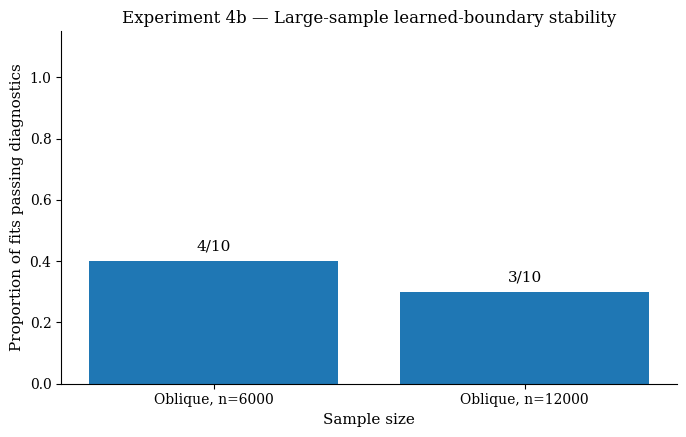

In [26]:
# Compare diagnostic stability for the oblique condition at n=6000 and n=12000.

oblique_6000 = diagnostics_exp4[
    (diagnostics_exp4["geometry"] == "oblique")
    & (diagnostics_exp4["n"] == 6000)
][
    ["geometry", "n", "fits", "passing_fits", "pass_rate"]
].copy()

plot_asym = pd.concat(
    [
        oblique_6000,
        diagnostics_exp4b[
            ["geometry", "n", "fits", "passing_fits", "pass_rate"]
        ],
    ],
    ignore_index=True,
)

labels = "Oblique, n=" + plot_asym["n"].astype(str)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    labels,
    plot_asym["pass_rate"],
)

ax.set_ylim(0, 1.15)
ax.set_ylabel("Proportion of fits passing diagnostics")
ax.set_xlabel("Sample size")
ax.set_title("Experiment 4b — Large-sample learned-boundary stability")

for bar, rate, n_ok, n_total in zip(
    bars,
    plot_asym["pass_rate"],
    plot_asym["passing_fits"],
    plot_asym["fits"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        float(rate) + 0.025,
        f"{int(n_ok)}/{int(n_total)}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp4b_large_sample.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Experiment 4c — Mode separation in failing learned-boundary fits

Experiment 4c examines the posterior structure behind the diagnostic failures in
Experiments 4a and 4b. For a representative failing oblique fit, posterior draws are
compared across chains to determine whether the chains occupy distinct regions of the
parameter space.

The boundary-direction draws are projected by chain, and the observed-data
log-likelihood is evaluated at each chain's posterior mean. This distinguishes
cross-chain mode separation from a conventional within-chain sampling failure and
allows the competing posterior explanations to be compared directly.

Selected failing fit: exp4 | oblique | n=6000 | rep=0 | max R-hat=1.737
Reconstructed world: n=6000, corruptions=178


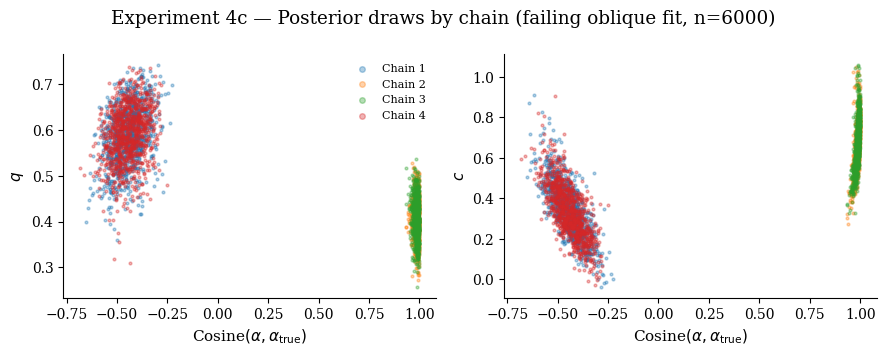

,chain,cos_alpha_mean,c_mean,q_mean,loglik_at_chain_mean
0,1,-0.447,0.342,0.588,-2644.18
1,2,0.986,0.674,0.405,-2610.63
2,3,0.986,0.671,0.406,-2610.61
3,4,-0.444,0.336,0.590,-2644.14


Maximum log-likelihood gap across chain posterior means: 33.57
Per observation: 0.00559
These are pointwise log-likelihoods evaluated at the chain posterior means, not integrated model evidence or Bayes factors.


In [27]:
# Experiment 4c: inspect mode separation in a failing learned-boundary fit.

# Select the failing oblique fit with the largest R-hat.
candidates = []

for _, row in results_exp4b.iterrows():
    if not row["diagnostics_pass"]:
        candidates.append(
            (
                "exp4b",
                "oblique",
                int(row["n"]),
                int(row["rep"]),
                float(row["max_rhat"]),
            )
        )

for _, row in results_exp4[
    (results_exp4["geometry"] == "oblique")
    & (results_exp4["n"] == 6000)
].iterrows():
    if not row["diagnostics_pass"]:
        candidates.append(
            (
                "exp4",
                "oblique",
                6000,
                int(row["rep"]),
                float(row["max_rhat"]),
            )
        )

if not candidates:
    raise RuntimeError(
        "No failing oblique fits found."
    )

tag, geometry, n_sel, rep_sel, rhat_sel = max(
    candidates,
    key=lambda x: x[4],
)

print(
    f"Selected failing fit: {tag} | {geometry} | "
    f"n={n_sel} | rep={rep_sel} | "
    f"max R-hat={rhat_sel:.3f}"
)


# Recover the fitted object from the current notebook session.
fit_key = (
    tag,
    geometry,
    n_sel,
    rep_sel,
)

if fit_key not in general_fits:
    raise RuntimeError(
        "Selected fit is not available in memory. "
        "Rerun the corresponding Experiment 4 fit first."
    )

fit_sel = general_fits[
    fit_key
]


# Reconstruct the corresponding simulated dataset.
if tag == "exp4b":
    seed_sel = (
        SEED
        + 80000
        + n_sel
        + rep_sel
    )
else:
    seed_sel = (
        SEED
        + 40000
        + 10000
        + n_sel
        + rep_sel
    )

world_sel = make_world(
    n=n_sel,
    alpha=ALPHA_OBLIQUE_GEOM,
    c=0.8,
    q=0.35,
    seed=seed_sel,
    beta=BETA_GEOM,
)

X_sel = world_sel["X"]
y_sel = world_sel[
    "y_obs"
].astype(int)

alpha_true_sel = world_sel[
    "alpha_true"
]

p_dim = X_sel.shape[1]

print(
    f"Reconstructed world: n={len(y_sel)}, "
    f"corruptions={int(world_sel['flips'].sum())}"
)


# Extract posterior draws separately by chain.
draws = fit_sel.draws(
    concat_chains=False
)

columns = list(
    fit_sel.column_names
)


def column_index(name):
    return columns.index(name)


i_beta0 = column_index(
    "beta0"
)

i_beta = [
    column_index(
        f"beta[{j + 1}]"
    )
    for j in range(p_dim)
]

i_alpha = [
    column_index(
        f"alpha[{j + 1}]"
    )
    for j in range(p_dim)
]

i_c = column_index("c")
i_q = column_index("q")

_, n_chains, _ = draws.shape


# Compare the posterior regions occupied by each chain.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 3.6),
)

chain_means = []

for ch in range(n_chains):

    alpha_draws = draws[
        :, ch, :
    ][:, i_alpha]

    cosine_draws = (
        alpha_draws
        @ alpha_true_sel
    ) / np.linalg.norm(
        alpha_draws,
        axis=1,
    )

    q_draws = draws[
        :, ch, i_q
    ]

    c_draws = draws[
        :, ch, i_c
    ]

    axes[0].scatter(
        cosine_draws,
        q_draws,
        s=4,
        alpha=0.35,
        label=f"Chain {ch + 1}",
    )

    axes[1].scatter(
        cosine_draws,
        c_draws,
        s=4,
        alpha=0.35,
    )

    chain_means.append(
        {
            "chain": ch + 1,
            "cos_alpha": float(
                cosine_draws.mean()
            ),
            "c": float(
                c_draws.mean()
            ),
            "q": float(
                q_draws.mean()
            ),
            "beta0": float(
                draws[
                    :, ch, i_beta0
                ].mean()
            ),
            "beta": draws[
                :, ch, :
            ][:, i_beta].mean(
                axis=0
            ),
            "alpha": alpha_draws.mean(
                axis=0
            ),
        }
    )

axes[0].set_xlabel(
    r"Cosine$(\alpha,\alpha_{\mathrm{true}})$"
)
axes[0].set_ylabel(
    r"$q$"
)

axes[1].set_xlabel(
    r"Cosine$(\alpha,\alpha_{\mathrm{true}})$"
)
axes[1].set_ylabel(
    r"$c$"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
    markerscale=2,
)

fig.suptitle(
    "Experiment 4c — Posterior draws by chain "
    f"(failing oblique fit, n={n_sel})"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "highrep_exp4c_mode_separation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "highrep_exp4c_mode_separation.pdf",
    bbox_inches="tight",
)

plt.show()


# Observed-data log-likelihood at each chain's posterior mean.
def general_total_loglik(
    beta0,
    beta,
    alpha,
    c,
    q,
    X,
    y,
    kappa=KAPPA,
):
    alpha = np.asarray(
        alpha,
        dtype=float,
    )
    alpha = (
        alpha
        / np.linalg.norm(alpha)
    )

    p_true = expit(
        beta0
        + X @ np.asarray(
            beta,
            dtype=float,
        )
    )

    region_weight = expit(
        kappa
        * (
            X @ alpha
            - c
        )
    )

    corruption_weight = (
        q
        * region_weight
    )

    likelihood = np.where(
        y == 1,
        (1.0 - corruption_weight)
        * p_true,
        (1.0 - p_true)
        + corruption_weight
        * p_true,
    )

    return float(
        np.log(
            np.clip(
                likelihood,
                1e-300,
                None,
            )
        ).sum()
    )


mode_rows = []

for chain_mean in chain_means:

    loglik = general_total_loglik(
        chain_mean["beta0"],
        chain_mean["beta"],
        chain_mean["alpha"],
        chain_mean["c"],
        chain_mean["q"],
        X_sel,
        y_sel,
    )

    mode_rows.append(
        {
            "chain": chain_mean["chain"],
            "cos_alpha_mean": round(
                chain_mean["cos_alpha"],
                3,
            ),
            "c_mean": round(
                chain_mean["c"],
                3,
            ),
            "q_mean": round(
                chain_mean["q"],
                3,
            ),
            "loglik_at_chain_mean": round(
                loglik,
                2,
            ),
        }
    )

mode_table = pd.DataFrame(
    mode_rows
)

display(
    mode_table
)

loglik_values = mode_table[
    "loglik_at_chain_mean"
]

gap = float(
    loglik_values.max()
    - loglik_values.min()
)

print(
    "Maximum log-likelihood gap across "
    f"chain posterior means: {gap:.2f}"
)

print(
    f"Per observation: "
    f"{gap / len(y_sel):.5f}"
)

print(
    "These are pointwise log-likelihoods evaluated "
    "at the chain posterior means, not integrated "
    "model evidence or Bayes factors."
)

## Experiment 4c (extended) — Mode structure across failing learned-boundary fits

This analysis extends the single-fit mode-separation check to all diagnostically
failing fits from Experiments 4a and 4b.

For each fit, the corresponding simulated dataset is reconstructed from its recorded
seed and checked against the recorded number of corruptions. Posterior means are then
calculated separately for each chain, and the observed-data log-likelihood is evaluated
at each chain posterior mean.

This allows the chain-level structure of the diagnostic failures to be compared across
datasets and shows whether the same type of posterior separation recurs consistently
across failing fits.

19 failing fits to analyse
('exp4', 'axis', 6000, 2) (corruptions=190, max R-hat=1.531)
('exp4', 'axis', 6000, 3) (corruptions=189, max R-hat=1.532)
('exp4', 'axis', 6000, 4) (corruptions=158, max R-hat=1.002)
('exp4', 'axis', 6000, 5) (corruptions=174, max R-hat=1.735)
('exp4', 'axis', 6000, 8) (corruptions=199, max R-hat=1.530)
('exp4', 'axis', 6000, 9) (corruptions=168, max R-hat=1.736)
('exp4', 'oblique', 6000, 0) (corruptions=178, max R-hat=1.737)
('exp4', 'oblique', 6000, 1) (corruptions=160, max R-hat=1.530)
('exp4', 'oblique', 6000, 6) (corruptions=170, max R-hat=1.534)
('exp4', 'oblique', 6000, 7) (corruptions=197, max R-hat=1.531)
('exp4', 'oblique', 6000, 8) (corruptions=168, max R-hat=1.529)
('exp4', 'oblique', 6000, 9) (corruptions=165, max R-hat=1.530)
('exp4b', 'oblique', 12000, 0) (corruptions=353, max R-hat=1.531)
('exp4b', 'oblique', 12000, 1) (corruptions=372, max R-hat=1.530)
('exp4b', 'oblique', 12000, 2) (corruptions=328, max R-hat=1.736)
('exp4b', 'oblique', 1200

,fit,chain,cos_alpha_mean,c_mean,q_mean,loglik_at_chain_mean
0,exp4|axis|n=6000|rep=2,1,0.987,0.854,0.466,-2534.93
1,exp4|axis|n=6000|rep=2,2,0.987,0.860,0.464,-2534.95
2,exp4|axis|n=6000|rep=2,3,0.987,0.858,0.464,-2534.95
3,exp4|axis|n=6000|rep=2,4,-0.331,0.311,0.676,-2580.40
4,exp4|axis|n=6000|rep=3,1,0.986,0.868,0.421,-2583.33
...,...,...,...,...,...,...
71,exp4b|oblique|n=12000|rep=6,4,0.996,0.865,0.461,-5227.49
72,exp4b|oblique|n=12000|rep=9,1,0.991,0.847,0.423,-5160.61
73,exp4b|oblique|n=12000|rep=9,2,-0.385,0.240,0.634,-5236.92
74,exp4b|oblique|n=12000|rep=9,3,0.992,0.840,0.425,-5160.59



Log-likelihood gap across chain posterior means for each failing fit:
fit
exp4b|oblique|n=12000|rep=0    49.63
exp4b|oblique|n=12000|rep=1    79.60
exp4b|oblique|n=12000|rep=2    70.31
exp4b|oblique|n=12000|rep=4    85.04
exp4b|oblique|n=12000|rep=5    56.22
exp4b|oblique|n=12000|rep=6    71.29
exp4b|oblique|n=12000|rep=9    76.34
exp4|axis|n=6000|rep=2         45.47
exp4|axis|n=6000|rep=3         38.61
exp4|axis|n=6000|rep=4          0.04
exp4|axis|n=6000|rep=5         42.72
exp4|axis|n=6000|rep=8         23.95
exp4|axis|n=6000|rep=9         27.59
exp4|oblique|n=6000|rep=0      33.57
exp4|oblique|n=6000|rep=1      41.03
exp4|oblique|n=6000|rep=6      24.79
exp4|oblique|n=6000|rep=7      21.26
exp4|oblique|n=6000|rep=8      29.82
exp4|oblique|n=6000|rep=9      32.67


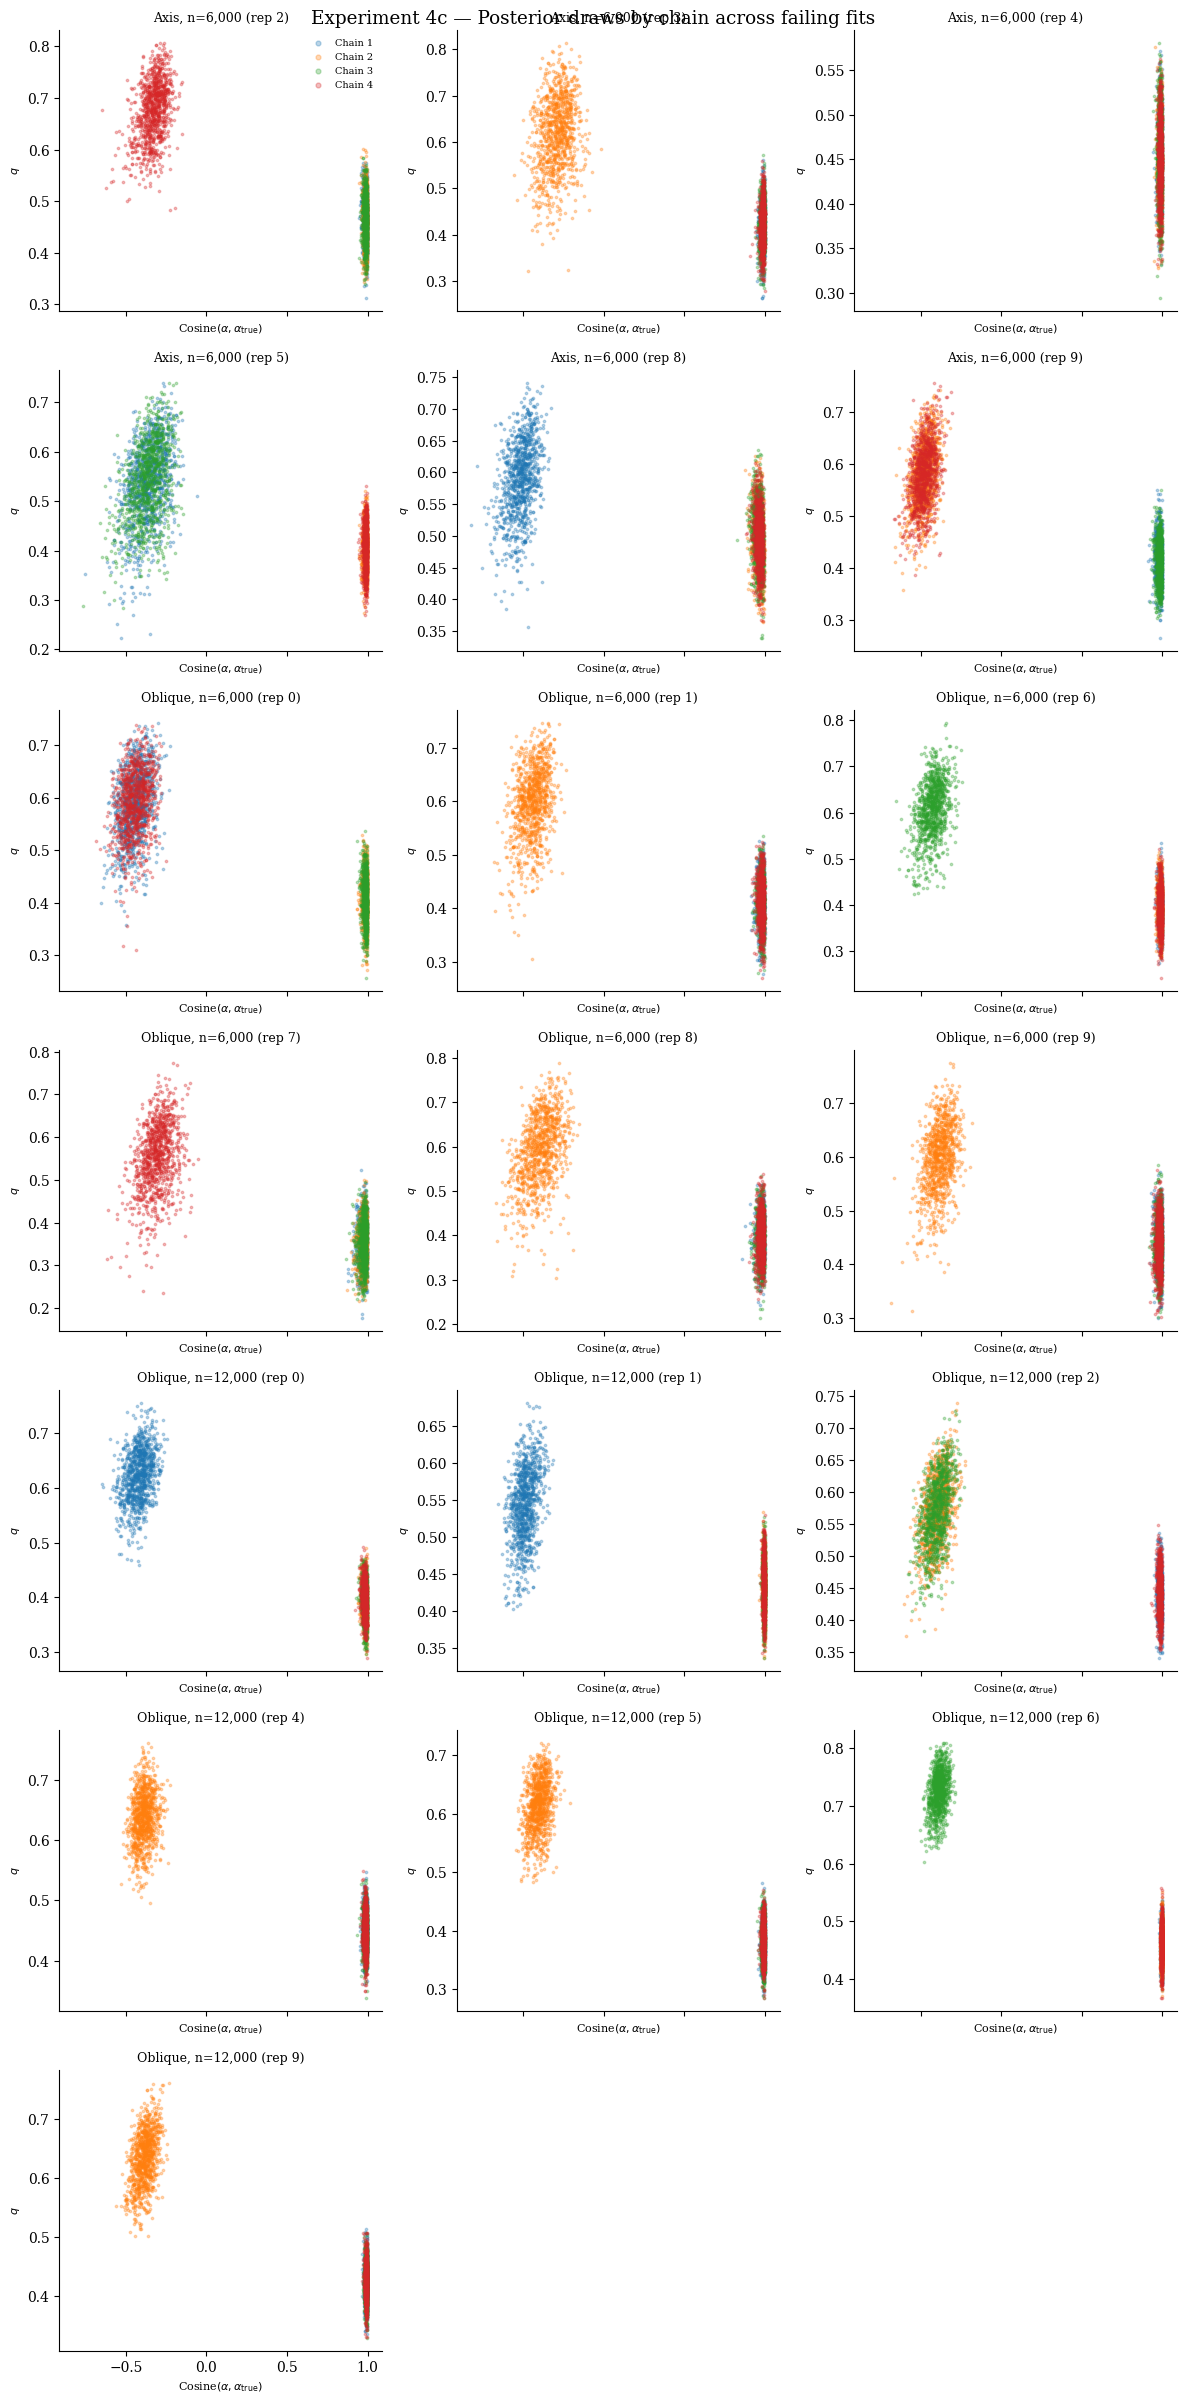

In [28]:
# Experiment 4c (extended): inspect chain-level structure across all failing fits.

failing = []

for _, row in results_exp4.iterrows():
    if not row["diagnostics_pass"]:
        failing.append(
            (
                "exp4",
                row["geometry"],
                int(row["n"]),
                int(row["rep"]),
                int(row["n_corrupted"]),
                float(row["max_rhat"]),
            )
        )

for _, row in results_exp4b.iterrows():
    if not row["diagnostics_pass"]:
        failing.append(
            (
                "exp4b",
                "oblique",
                int(row["n"]),
                int(row["rep"]),
                int(row["n_corrupted"]),
                float(row["max_rhat"]),
            )
        )

print(f"{len(failing)} failing fits to analyse")

for fit_info in failing:
    print(
        fit_info[:4],
        f"(corruptions={fit_info[4]}, "
        f"max R-hat={fit_info[5]:.3f})",
    )


def alpha_for(geometry):
    if geometry == "axis":
        return ALPHA_AXIS_GEOM
    return ALPHA_OBLIQUE_GEOM


def seed_for(tag, geometry, n, rep):
    if tag == "exp4b":
        return SEED + 80000 + n + rep

    return (
        SEED
        + 40000
        + (10000 if geometry == "oblique" else 0)
        + n
        + rep
    )


rows = []
panels = []

for (
    tag,
    geometry,
    n_fit,
    rep_fit,
    n_corrupted_recorded,
    rhat_fit,
) in failing:

    seed = seed_for(
        tag,
        geometry,
        n_fit,
        rep_fit,
    )

    world = make_world(
        n=n_fit,
        alpha=alpha_for(geometry),
        c=0.8,
        q=0.35,
        seed=seed,
        beta=BETA_GEOM,
    )

    n_corrupted = int(
        world["flips"].sum()
    )

    assert n_corrupted == n_corrupted_recorded, (
        f"Reconstruction mismatch for "
        f"{(tag, geometry, n_fit, rep_fit)}: "
        f"{n_corrupted} versus "
        f"{n_corrupted_recorded}"
    )

    X_fit = world["X"]
    y_fit = world[
        "y_obs"
    ].astype(int)

    alpha_true = world[
        "alpha_true"
    ]

    fit_key = (
        tag,
        geometry,
        n_fit,
        rep_fit,
    )

    fit = general_fits.get(
        fit_key
    )

    if fit is None:
        print(
            f"Refitting {fit_key} for chain-level analysis"
        )

        fit = fit_general_world(
            world,
            seed + 1,
        )

        general_fits[
            fit_key
        ] = fit

    draws = fit.draws(
        concat_chains=False
    )

    columns = list(
        fit.column_names
    )

    p_dim = X_fit.shape[1]

    i_beta0 = columns.index(
        "beta0"
    )

    i_beta = [
        columns.index(
            f"beta[{j + 1}]"
        )
        for j in range(p_dim)
    ]

    i_alpha = [
        columns.index(
            f"alpha[{j + 1}]"
        )
        for j in range(p_dim)
    ]

    i_c = columns.index("c")
    i_q = columns.index("q")

    chain_points = []

    for ch in range(
        draws.shape[1]
    ):
        alpha_draws = draws[
            :, ch, :
        ][:, i_alpha]

        cosine_draws = (
            alpha_draws
            @ alpha_true
        ) / np.linalg.norm(
            alpha_draws,
            axis=1,
        )

        beta0_mean = float(
            draws[
                :, ch, i_beta0
            ].mean()
        )

        beta_mean = draws[
            :, ch, :
        ][:, i_beta].mean(
            axis=0
        )

        alpha_mean = alpha_draws.mean(
            axis=0
        )

        c_mean = float(
            draws[
                :, ch, i_c
            ].mean()
        )

        q_mean = float(
            draws[
                :, ch, i_q
            ].mean()
        )

        loglik = general_total_loglik(
            beta0_mean,
            beta_mean,
            alpha_mean,
            c_mean,
            q_mean,
            X_fit,
            y_fit,
        )

        rows.append(
            {
                "fit": (
                    f"{tag}|{geometry}|"
                    f"n={n_fit}|rep={rep_fit}"
                ),
                "chain": ch + 1,
                "cos_alpha_mean": round(
                    float(
                        cosine_draws.mean()
                    ),
                    3,
                ),
                "c_mean": round(
                    c_mean,
                    3,
                ),
                "q_mean": round(
                    q_mean,
                    3,
                ),
                "loglik_at_chain_mean": round(
                    loglik,
                    2,
                ),
            }
        )

        chain_points.append(
            (
                cosine_draws,
                draws[:, ch, i_q],
            )
        )

    geometry_label = (
        "Axis"
        if geometry == "axis"
        else "Oblique"
    )

    panels.append(
        (
            f"{geometry_label}, "
            f"n={n_fit:,} "
            f"(rep {rep_fit})",
            chain_points,
        )
    )


extended_mode_table = pd.DataFrame(
    rows
)

display(
    extended_mode_table
)


loglik_gaps = (
    extended_mode_table
    .groupby("fit")[
        "loglik_at_chain_mean"
    ]
    .agg(
        lambda values:
        values.max()
        - values.min()
    )
)

print(
    "\nLog-likelihood gap across chain "
    "posterior means for each failing fit:"
)

print(
    loglik_gaps
    .round(2)
    .to_string()
)


n_panels = len(
    panels
)

n_cols = min(
    3,
    max(1, n_panels),
)

n_rows = int(
    np.ceil(
        n_panels / n_cols
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(
        4.0 * n_cols,
        3.5 * n_rows,
    ),
    sharex=True,
    squeeze=False,
)

for ax in axes.ravel()[
    n_panels:
]:
    ax.set_visible(
        False
    )

for ax, (title, points) in zip(
    axes.ravel(),
    panels,
):
    for ch, (
        cosine_draws,
        q_draws,
    ) in enumerate(points):

        ax.scatter(
            cosine_draws,
            q_draws,
            s=3,
            alpha=0.3,
            label=f"Chain {ch + 1}",
        )

    ax.set_title(
        title,
        fontsize=9,
    )

    ax.set_xlabel(
        r"Cosine$(\alpha,\alpha_{\mathrm{true}})$",
        fontsize=8,
    )

    ax.set_ylabel(
        r"$q$",
        fontsize=8,
    )

axes[0, 0].legend(
    frameon=False,
    fontsize=7,
    markerscale=2,
)

fig.suptitle(
    "Experiment 4c — Posterior draws by chain "
    "across failing fits"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "highrep_exp4c_extended_all_failing.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR
    / "highrep_exp4c_extended_all_failing.pdf",
    bbox_inches="tight",
)

plt.show()

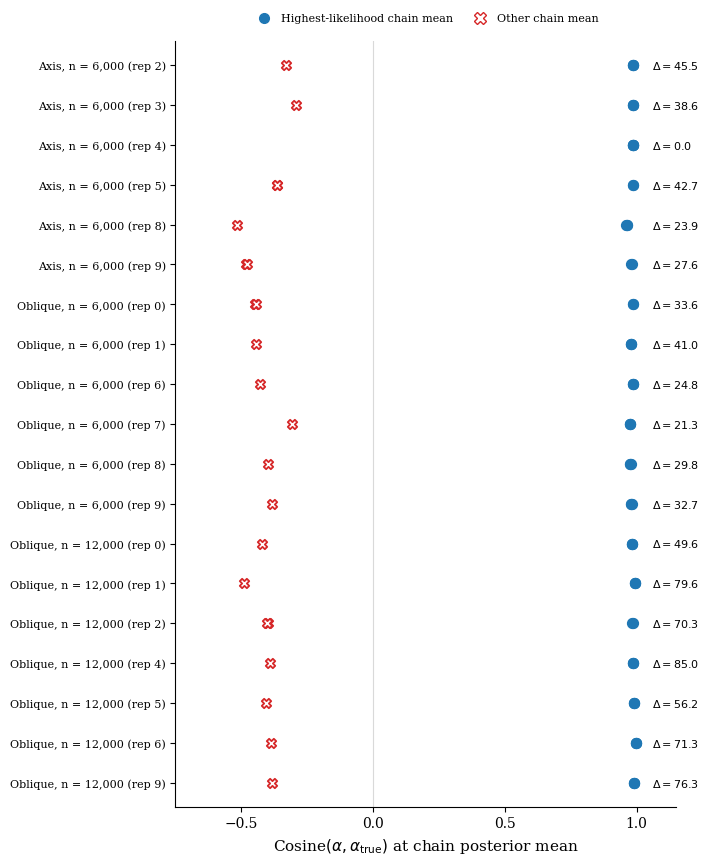

Delta is the max-minus-min observed-data log-likelihood across chain posterior means for each fit.


In [30]:
# Summarise chain separation across the failing learned-boundary fits.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def pretty_label(key):
    tag, geometry, n_part, rep_part = key.split("|")
    n_value = int(n_part.split("=")[1])
    rep_value = int(rep_part.split("=")[1])

    geometry_label = "Axis" if geometry == "axis" else "Oblique"

    return (
        f"{geometry_label}, n = {n_value:,} "
        f"(rep {rep_value})"
    )


def sort_key(key):
    tag, geometry, n_part, rep_part = key.split("|")

    return (
        0 if geometry == "axis" else 1,
        int(n_part.split("=")[1]),
        int(rep_part.split("=")[1]),
    )


order = sorted(
    extended_mode_table["fit"].unique(),
    key=sort_key,
)

label_map = {
    key: pretty_label(key)
    for key in order
}


fig, ax = plt.subplots(
    figsize=(
        7.2,
        max(4.5, 0.42 * len(order) + 0.8),
    )
)


for i, key in enumerate(order):

    sub = extended_mode_table[
        extended_mode_table["fit"] == key
    ]

    y = len(order) - 1 - i

    best_loglik = sub[
        "loglik_at_chain_mean"
    ].max()

    for _, row in sub.iterrows():

        highest = np.isclose(
            row["loglik_at_chain_mean"],
            best_loglik,
            atol=1.0,
        )

        ax.scatter(
            row["cos_alpha_mean"],
            y,
            s=46,
            marker="o" if highest else "X",
            facecolor="#1f77b4" if highest else "white",
            edgecolor="#1f77b4" if highest else "#d62728",
            linewidth=1.3,
            zorder=3,
        )

    gap = (
        sub["loglik_at_chain_mean"].max()
        - sub["loglik_at_chain_mean"].min()
    )

    ax.annotate(
        rf"$\Delta={gap:.1f}$",
        xy=(1.06, y),
        va="center",
        fontsize=8,
        annotation_clip=False,
    )


ax.axvline(
    0,
    color="0.85",
    linewidth=0.8,
    zorder=1,
)

ax.set_yticks(
    range(len(order))
)

ax.set_yticklabels(
    [
        label_map[key]
        for key in reversed(order)
    ],
    fontsize=8,
)

ax.set_xlabel(
    r"Cosine$(\alpha,\alpha_{\mathrm{true}})$ "
    "at chain posterior mean"
)

ax.set_xlim(
    -0.75,
    1.15,
)

ax.set_ylim(
    -0.6,
    len(order) - 0.4,
)

ax.set_xticks(
    [-0.5, 0, 0.5, 1.0]
)

for side in (
    "top",
    "right",
):
    ax.spines[
        side
    ].set_visible(False)


ax.legend(
    handles=[
        Line2D(
            [],
            [],
            marker="o",
            color="none",
            markerfacecolor="#1f77b4",
            markeredgecolor="#1f77b4",
            markersize=7,
            label="Highest-likelihood chain mean",
        ),
        Line2D(
            [],
            [],
            marker="X",
            color="none",
            markerfacecolor="white",
            markeredgecolor="#d62728",
            markersize=8,
            label="Other chain mean",
        ),
    ],
    frameon=False,
    fontsize=8,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    handletextpad=0.5,
    columnspacing=1.5,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "highrep_exp4c_summary_panel.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "highrep_exp4c_summary_panel.pdf",
    bbox_inches="tight",
)

plt.show()

print(
    "Delta is the max-minus-min observed-data log-likelihood "
    "across chain posterior means for each fit."
)

## Confident learning benchmark

Confident learning is retained as an external label-error detector. It is not designed
to estimate $c$, $q$ or $\alpha$, so the comparison is restricted to observation-level
localisation.

The benchmark uses five matched $q=0.35$, $n=3000$ simulated datasets from the
Experiment 2 setting. Ranked AUC compares the observation-level rankings, while
Precision@$k$ uses the true number of simulated corruptions as the review budget.
The same $k$ is used for both methods within each dataset.

In [31]:
# Compare Bayesian localisation with confident learning on 20 matched datasets.

def cleanlab_score(X, y_obs):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
    )

    pred_probs = cross_val_predict(
        model,
        X,
        y_obs,
        cv=5,
        method="predict_proba",
    )

    return 1.0 - get_label_quality_scores(
        labels=y_obs.astype(int),
        pred_probs=pred_probs,
    )


q_bench = 0.35
BENCHMARK_REPS = 20

benchmark_rows = []

for rep in range(BENCHMARK_REPS):
    seed_bench = SEED + 20000 + int(q_bench * 1000) + rep

    world_bench = make_world(
        n=N_EXP2,
        alpha=ALPHA_AXIS,
        c=0.8,
        q=q_bench,
        seed=seed_bench,
    )

    z_path = (
        REPLICATE_DIR
        / f"exp2_q035_rep{rep:02d}_zmean.npy"
    )

    if z_path.exists():
        bayes_score = np.load(z_path)

    else:
        fit_bench = fit_axis_world(
            world_bench,
            seed_bench + 1,
        )

        bayes = summarise_axis_fit(
            fit_bench,
            world_bench,
        )

        bayes_score = bayes["z_mean"]

        np.save(
            z_path,
            np.asarray(
                bayes_score,
                dtype=np.float32,
            ),
        )

        del fit_bench, bayes
        gc.collect()

    cl_score = cleanlab_score(
        world_bench["X"],
        world_bench["y_obs"],
    )

    for method, score in [
        ("Bayesian posterior", bayes_score),
        ("Confident learning", cl_score),
    ]:
        benchmark_rows.append(
            {
                "rep": rep,
                "method": method,
                "ranked_auc": localisation_auc(
                    world_bench["flips"],
                    world_bench["y_obs"],
                    score,
                ),
                "precision_at_k": precision_at_k(
                    world_bench["flips"],
                    world_bench["y_obs"],
                    score,
                ),
            }
        )


benchmark_results = pd.DataFrame(
    benchmark_rows
)

benchmark_summary = (
    benchmark_results
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        ranked_auc_mean=("ranked_auc", "mean"),
        ranked_auc_sd=("ranked_auc", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
    )
)

display(
    benchmark_results
)

display(
    benchmark_summary
)

,rep,method,ranked_auc,precision_at_k
0,0,Bayesian posterior,0.976902,0.615385
1,0,Confident learning,0.886052,0.333333
2,1,Bayesian posterior,0.969485,0.544304
3,1,Confident learning,0.845890,0.354430
4,2,Bayesian posterior,0.978989,0.666667
5,2,Confident learning,0.876463,0.321429
6,3,Bayesian posterior,0.967165,0.593407
7,3,Confident learning,0.822271,0.329670
8,4,Bayesian posterior,0.964767,0.591398
9,4,Confident learning,0.825591,0.290323


,method,ranked_auc_mean,ranked_auc_sd,precision_at_k_mean,precision_at_k_sd
0,Bayesian posterior,0.965127,0.007319,0.569639,0.046115
1,Confident learning,0.830390,0.025354,0.298814,0.040849


### Interpretation

Across the 20 matched simulated datasets, the Bayesian posterior achieves mean ranked
AUC 0.965 compared with 0.830 for confident learning, and mean Precision@$k$ 0.570
compared with 0.299.

This comparison is favourable to the Bayesian method because the simulated
data-generating mechanism matches its structural assumptions. The result is therefore
specific to this correctly specified structured-corruption setting rather than a claim
of universal superiority. Confident learning ranks suspicious labels using classifier
probabilities, whereas the Bayesian approach explicitly models the covariate-dependent
corruption mechanism and returns posterior corruption probabilities.

## Final sampler diagnostic audit

All stored Stan fits are checked using the same diagnostic gate. For the core sampled
parameters, a fit passes when:

- there are no divergent transitions;
- there are no maximum-tree-depth hits;
- $\widehat R\leq1.05$; and
- bulk ESS $\geq100$.

This gate is applied consistently across Experiments 1--4b. In Experiments 4a--4b,
the diagnostics are also part of the result because cross-chain disagreement is relevant
to the estimability of the learned boundary.

The gate is a screening rule rather than a theoretical definition of identifiability.
The problematic learned-boundary fits are not borderline cases: their $\widehat R$
values are around $1.53$--$1.74$ and their minimum bulk ESS values are about $6$--$7$.

In [32]:
# Check the diagnostic gate across all simulation fits.

RHAT_LIMIT = 1.05
ESS_LIMIT = 100

diagnostic_frames = []

for label, frame in [
    ("exp1", globals().get("results_exp1")),
    ("exp2", globals().get("results_exp2")),
    ("exp3a", globals().get("results_exp3")),
    ("exp3b", globals().get("results_exp3b")),
    ("exp4a", globals().get("results_exp4")),
    ("exp4b", globals().get("results_exp4b")),
]:
    if isinstance(frame, pd.DataFrame):
        temp = frame.copy()
        temp["analysis"] = label
        diagnostic_frames.append(temp)


diagnostics = pd.concat(
    diagnostic_frames,
    ignore_index=True,
)


problem_fits = diagnostics[
    (diagnostics["divergences"] > 0)
    | (diagnostics["max_treedepth_hits"] > 0)
    | (diagnostics["max_rhat"] > RHAT_LIMIT)
    | (diagnostics["min_ess_bulk"] < ESS_LIMIT)
].copy()


print(
    f"Diagnostic gate: R-hat <= {RHAT_LIMIT}, "
    f"bulk ESS >= {ESS_LIMIT}, with no divergences "
    "or maximum-tree-depth hits"
)

print(
    f"Total replicate fits audited: {len(diagnostics)}"
)

print(
    f"Fits failing the gate: {len(problem_fits)}"
)


display(
    diagnostics[
        [
            column
            for column in [
                "analysis",
                "geometry",
                "n",
                "q_true",
                "c_true",
                "mu5",
                "rep",
                "max_rhat",
                "min_ess_bulk",
                "divergences",
                "max_treedepth_hits",
                "diagnostics_pass",
            ]
            if column in diagnostics.columns
        ]
    ]
)


display(
    problem_fits[
        [
            column
            for column in [
                "analysis",
                "geometry",
                "n",
                "q_true",
                "c_true",
                "mu5",
                "rep",
                "max_rhat",
                "min_ess_bulk",
                "divergences",
                "max_treedepth_hits",
                "diagnostics_pass",
            ]
            if column in problem_fits.columns
        ]
    ]
)

Diagnostic gate: R-hat <= 1.05, bulk ESS >= 100, with no divergences or maximum-tree-depth hits
Total replicate fits audited: 410
Fits failing the gate: 19


,analysis,geometry,n,q_true,c_true,mu5,rep,max_rhat,min_ess_bulk,divergences,max_treedepth_hits,diagnostics_pass
0,exp1,NaN,750,0.35,NaN,NaN,0,1.00280,2229.94000,0,0,True
1,exp1,NaN,750,0.35,NaN,NaN,1,1.00278,2024.85000,0,0,True
2,exp1,NaN,750,0.35,NaN,NaN,2,1.00232,1760.13000,0,0,True
3,exp1,NaN,750,0.35,NaN,NaN,3,1.00260,2151.77000,0,0,True
4,exp1,NaN,750,0.35,NaN,NaN,4,1.00265,2251.32000,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
405,exp4b,oblique,12000,0.35,NaN,NaN,5,1.53476,7.15835,0,0,False
406,exp4b,oblique,12000,0.35,NaN,NaN,6,1.53044,7.14870,0,0,False
407,exp4b,oblique,12000,0.35,NaN,NaN,7,1.00206,1662.13000,0,0,True
408,exp4b,oblique,12000,0.35,NaN,NaN,8,1.00237,2285.73000,0,0,True


,analysis,geometry,n,q_true,c_true,mu5,rep,max_rhat,min_ess_bulk,divergences,max_treedepth_hits,diagnostics_pass
372,exp4a,axis,6000,0.35,NaN,NaN,2,1.53136,7.16146,0,0,False
373,exp4a,axis,6000,0.35,NaN,NaN,3,1.53177,7.14578,0,0,False
374,exp4a,axis,6000,0.35,NaN,NaN,4,1.00229,1927.88000,1,0,False
375,exp4a,axis,6000,0.35,NaN,NaN,5,1.73517,6.10627,0,0,False
378,exp4a,axis,6000,0.35,NaN,NaN,8,1.53048,7.16941,0,0,False
379,exp4a,axis,6000,0.35,NaN,NaN,9,1.73575,6.09344,0,0,False
390,exp4a,oblique,6000,0.35,NaN,NaN,0,1.73677,6.10022,0,0,False
391,exp4a,oblique,6000,0.35,NaN,NaN,1,1.53048,7.15051,0,0,False
396,exp4a,oblique,6000,0.35,NaN,NaN,6,1.53411,7.14629,0,0,False
397,exp4a,oblique,6000,0.35,NaN,NaN,7,1.53100,7.14462,0,0,False


## Replicate storage and Monte Carlo stability check

Each simulated dataset is stored separately so that between-dataset variability can be
examined directly. For the main summary quantities, running means are plotted against
the number of replicates to assess how stable the reported averages are as additional
datasets are included.

Per-replicate results written to /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/replicate_results
  exp1_information: 80 rows
  exp2_corruption_strength: 100 rows
  exp3a_susceptible_population: 100 rows
  exp3b_population_mass: 80 rows
  exp4a_learned_boundary: 40 rows
  exp4b_large_sample: 10 rows
  confident_learning_benchmark: 40 rows

=== Experiment 1: localisation_auc ===


,n,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,750,localisation_auc,0.9630,0.0223,20,8
1,1500,localisation_auc,0.9684,0.0082,20,6
2,3000,localisation_auc,0.9645,0.0069,20,19
3,6000,localisation_auc,0.9655,0.0030,20,2



=== Experiment 1: c_abs_error ===


,n,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,750,c_abs_error,0.1088,0.0924,20,19
1,1500,c_abs_error,0.0866,0.0630,20,16
2,3000,c_abs_error,0.0802,0.0480,20,19
3,6000,c_abs_error,0.0791,0.0527,20,16



=== Experiment 1: q_abs_error ===


...

,c_true,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,0.00,localisation_auc,0.9254,0.0065,20,10
1,0.50,localisation_auc,0.9490,0.0074,20,2
2,0.80,localisation_auc,0.9663,0.0066,20,7
3,1.28,localisation_auc,0.9825,0.0047,20,1
4,1.65,localisation_auc,0.9885,0.0071,20,6



=== Experiment 3b: localisation_auc ===


,mu5,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,-1.0,localisation_auc,0.9924,0.0036,20,2
1,-0.5,localisation_auc,0.9815,0.0048,20,2
2,0.0,localisation_auc,0.9671,0.0044,20,1
3,0.5,localisation_auc,0.9414,0.0081,20,1



=== Confident learning benchmark: ranked_auc ===


,method,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,Bayesian posterior,ranked_auc,0.9651,0.0073,20,4
1,Confident learning,ranked_auc,0.8304,0.0254,20,9


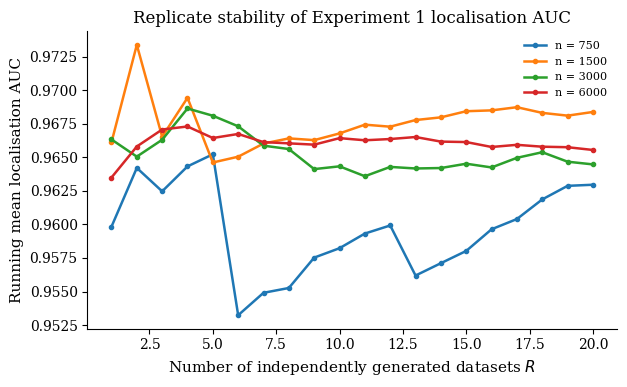

In [33]:
# Store replicate-level results and check stability of the main averages.

per_replicate = {
    "exp1_information": "results_exp1",
    "exp2_corruption_strength": "results_exp2",
    "exp3a_susceptible_population": "results_exp3",
    "exp3b_population_mass": "results_exp3b",
    "exp4a_learned_boundary": "results_exp4",
    "exp4b_large_sample": "results_exp4b",
    "confident_learning_benchmark": "benchmark_results",
}

saved = []

for stem, varname in per_replicate.items():
    frame = globals().get(varname)

    if isinstance(frame, pd.DataFrame):
        path = REPLICATE_DIR / f"{stem}_per_replicate.csv"
        frame.to_csv(path, index=False)
        saved.append((stem, len(frame)))

print(
    "Per-replicate results written to",
    REPLICATE_DIR.resolve(),
)

for stem, n_rows in saved:
    print(
        f"  {stem}: {n_rows} rows"
    )


def running_mean_table(frame, group_cols, metric):
    """Running mean after each additional replicate."""

    rows = []

    for keys, sub in frame.groupby(
        group_cols,
        sort=True,
    ):
        sub = sub.sort_values("rep")

        values = sub[
            metric
        ].to_numpy(dtype=float)

        running_mean = (
            np.cumsum(values)
            / np.arange(1, len(values) + 1)
        )

        if not isinstance(keys, tuple):
            keys = (keys,)

        for r, value in enumerate(
            running_mean,
            start=1,
        ):
            row = dict(
                zip(group_cols, keys)
            )

            row.update(
                {
                    "R": r,
                    "running_mean": value,
                }
            )

            rows.append(row)

    return pd.DataFrame(rows)


def stability_report(
    frame,
    group_cols,
    metric,
    decimals=2,
):
    """Find when the rounded running mean reaches its final value."""

    table = running_mean_table(
        frame,
        group_cols,
        metric,
    )

    rows = []

    for keys, sub in table.groupby(
        group_cols,
        sort=True,
    ):
        sub = sub.sort_values("R")

        rounded = sub[
            "running_mean"
        ].round(decimals).to_numpy()

        final_value = rounded[-1]
        settled_at = len(rounded)

        for i in range(
            len(rounded) - 1,
            -1,
            -1,
        ):
            if rounded[i] == final_value:
                settled_at = i + 1
            else:
                break

        if not isinstance(keys, tuple):
            keys = (keys,)

        mask = np.logical_and.reduce(
            [
                frame[column] == value
                for column, value
                in zip(group_cols, keys)
            ]
        )

        row = dict(
            zip(group_cols, keys)
        )

        row.update(
            {
                "metric": metric,
                "final_mean": sub[
                    "running_mean"
                ].iloc[-1],
                "sd_across_replicates": frame.loc[
                    mask,
                    metric,
                ].std(ddof=1),
                "R_total": len(rounded),
                f"R_settled_{decimals}dp": settled_at,
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)


STABILITY_CHECKS = [
    ("Experiment 1", "results_exp1", ["n"], "localisation_auc"),
    ("Experiment 1", "results_exp1", ["n"], "c_abs_error"),
    ("Experiment 1", "results_exp1", ["n"], "q_abs_error"),
    ("Experiment 2", "results_exp2", ["q_true"], "localisation_auc"),
    ("Experiment 3a", "results_exp3", ["c_true"], "localisation_auc"),
    ("Experiment 3b", "results_exp3b", ["mu5"], "localisation_auc"),
    (
        "Confident learning benchmark",
        "benchmark_results",
        ["method"],
        "ranked_auc",
    ),
]


for label, varname, group_cols, metric in STABILITY_CHECKS:
    frame = globals().get(varname)

    if not isinstance(frame, pd.DataFrame):
        continue

    missing = [
        column
        for column in group_cols + [metric]
        if column not in frame.columns
    ]

    if missing:
        continue

    print(
        f"\n=== {label}: {metric} ==="
    )

    display(
        stability_report(
            frame,
            group_cols,
            metric,
            decimals=2,
        ).round(4)
    )


# Plot the running localisation-AUC means from Experiment 1.
table = running_mean_table(
    results_exp1,
    ["n"],
    "localisation_auc",
)

fig, ax = plt.subplots(
    figsize=(6.4, 4.0)
)

for n_value, sub in table.groupby(
    "n",
    sort=True,
):
    ax.plot(
        sub["R"],
        sub["running_mean"],
        marker="o",
        markersize=3,
        label=f"n = {n_value}",
    )

ax.set_xlabel(
    "Number of independently generated datasets $R$"
)

ax.set_ylabel(
    "Running mean localisation AUC"
)

ax.set_title(
    "Replicate stability of Experiment 1 localisation AUC"
)

ax.legend(
    frameon=False,
    fontsize=8,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "highrep_fig_replicate_stability.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## High-replication uncertainty figures

These plots show the mean $\pm$ one standard deviation across independently generated
datasets. The error bars therefore represent between-dataset variability, not confidence
intervals for the mean.

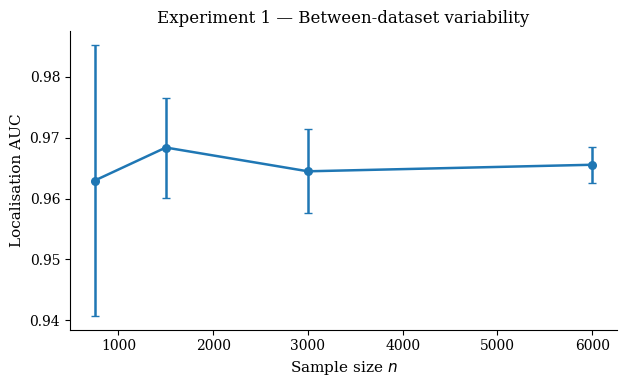

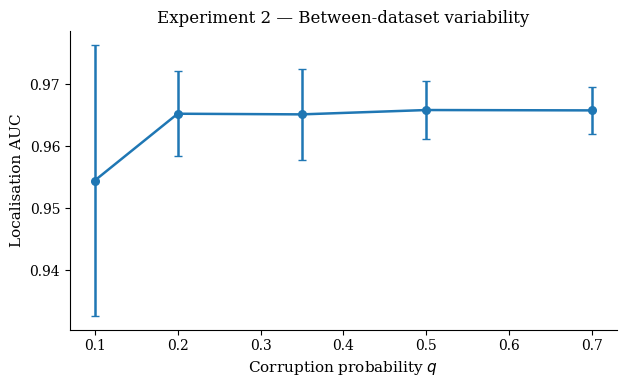

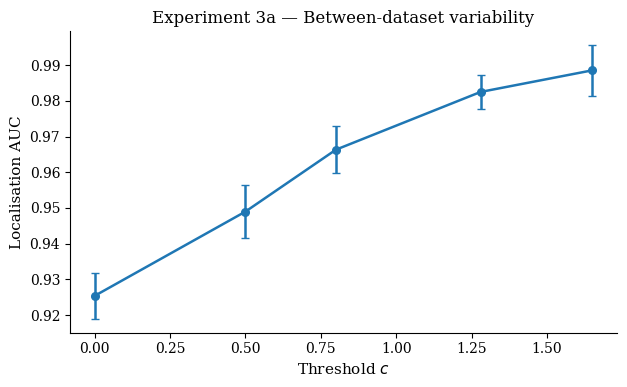

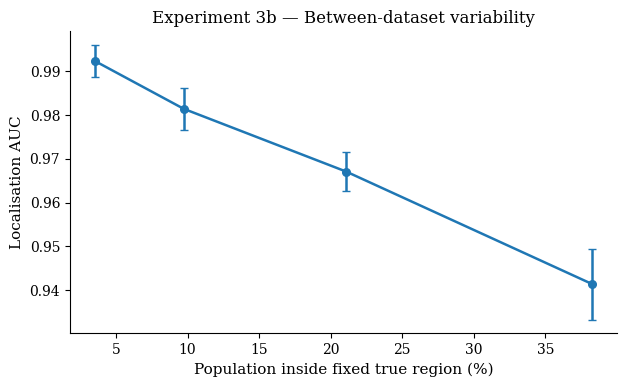

In [34]:
# Plot mean localisation AUC ± one SD across simulated datasets.

def errorbar_plot(
    x,
    mean,
    sd,
    xlabel,
    ylabel,
    title,
    filename,
):
    fig, ax = plt.subplots(
        figsize=(6.4, 4.0)
    )

    ax.errorbar(
        x,
        mean,
        yerr=sd,
        marker="o",
        capsize=3,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


if "summary_exp1" in globals():
    errorbar_plot(
        summary_exp1["n"],
        summary_exp1["localisation_auc_mean"],
        summary_exp1["localisation_auc_sd"],
        "Sample size $n$",
        "Localisation AUC",
        "Experiment 1 — Between-dataset variability",
        "highrep_exp1_auc_errorbars.png",
    )


if "summary_exp2" in globals():
    errorbar_plot(
        summary_exp2["q_true"],
        summary_exp2["localisation_auc_mean"],
        summary_exp2["localisation_auc_sd"],
        "Corruption probability $q$",
        "Localisation AUC",
        "Experiment 2 — Between-dataset variability",
        "highrep_exp2_auc_errorbars.png",
    )


if "summary_exp3" in globals():
    errorbar_plot(
        summary_exp3["c_true"],
        summary_exp3["localisation_auc_mean"],
        summary_exp3["localisation_auc_sd"],
        "Threshold $c$",
        "Localisation AUC",
        "Experiment 3a — Between-dataset variability",
        "highrep_exp3a_auc_errorbars.png",
    )


if "summary_exp3b" in globals():
    errorbar_plot(
        100 * summary_exp3b["region_share_mean"],
        summary_exp3b["localisation_auc_mean"],
        summary_exp3b["localisation_auc_sd"],
        "Population inside fixed true region (%)",
        "Localisation AUC",
        "Experiment 3b — Between-dataset variability",
        "highrep_exp3b_auc_errorbars.png",
    )

## What Chapter 1 establishes before Chapter 2

The simulation study gives four practical lessons for the applications:

1. **Information depends on the number of actual corruption events, not sample size alone.**

2. **Localisation and full mechanism recovery are different inferential targets.**

3. **Susceptible-population geometry and population mass both affect recoverability.**

4. **When the boundary direction must be learned, competing posterior explanations can limit practical estimability.** Experiment 4b shows that increasing the sample size to $n=12000$ does not resolve this instability in the oblique setting over the range studied.

Chapter 2 therefore treats these lessons as diagnostics rather than assuming that a fitted corruption mechanism is automatically interpretable.

## 7. Takeaway

The simulation study separates two questions that are easy to conflate: whether
individual corrupted observations can be localised, and whether the parameters governing
the corruption mechanism can themselves be recovered reliably.

The axis-supplied experiments show how recovery changes with sample information,
corruption strength and the population exposed to corruption. Observation-level
localisation is often strong even when individual mechanism parameters are recovered
less precisely.

When the boundary direction must also be learned, inference becomes more difficult.
Experiment 4a shows that some simulated datasets support highly accurate recovery,
while others exhibit clear cross-chain disagreement between competing posterior
explanations. Experiment 4b increases the difficult oblique setting to $n=12000$, but
only 3 of 10 fits pass the common diagnostic gate. The remaining failures show the same
cross-chain instability seen at $n=6000$.

These findings concern practical identifiability and estimability over the sample sizes
studied, not structural non-identifiability. They provide the reference frame for
Chapter 2: posterior corruption probabilities may remain useful for localisation, but
interpretation of an estimated corruption mechanism should depend on the available
information, the geometry of the susceptible population and evidence that the posterior
has been explored reliably.

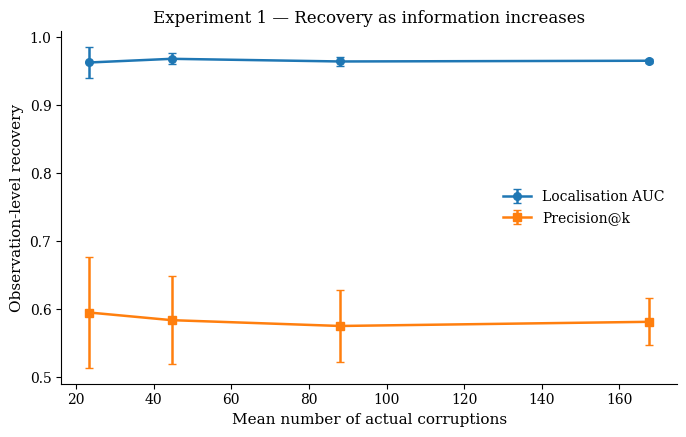

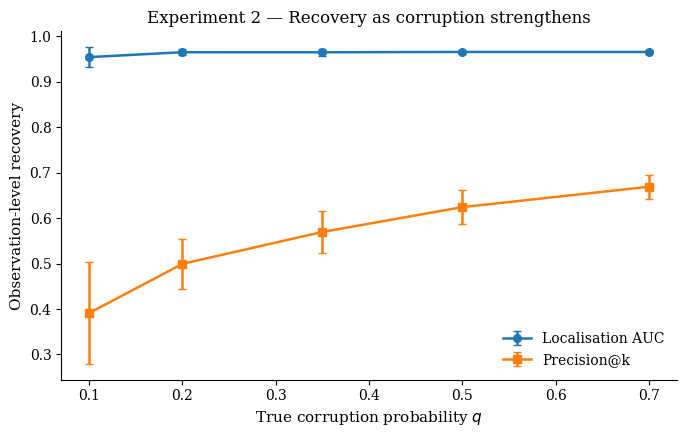

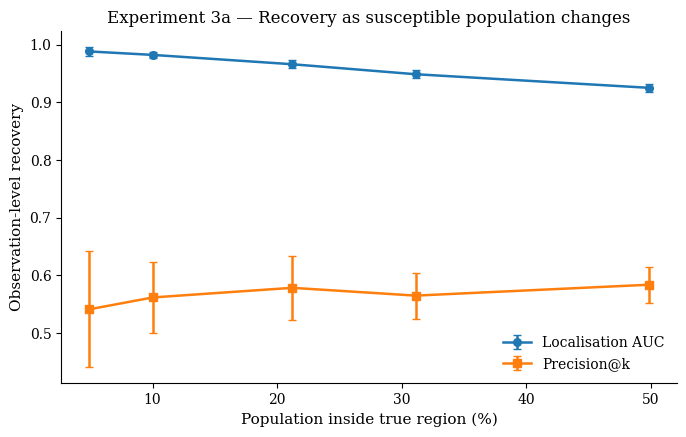

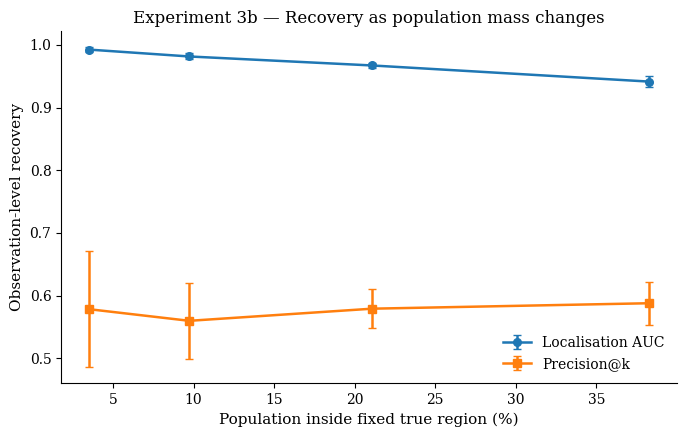

In [35]:
# Plot mean recovery ± one SD across independently generated datasets.

# Experiment 1
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    summary_exp1["corruptions_mean"],
    summary_exp1["localisation_auc_mean"],
    yerr=summary_exp1["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    summary_exp1["corruptions_mean"],
    summary_exp1["precision_at_k_mean"],
    yerr=summary_exp1["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("Mean number of actual corruptions")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 1 — Recovery as information increases")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_exp1_information.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Experiment 2
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    summary_exp2["q_true"],
    summary_exp2["localisation_auc_mean"],
    yerr=summary_exp2["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    summary_exp2["q_true"],
    summary_exp2["precision_at_k_mean"],
    yerr=summary_exp2["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("True corruption probability $q$")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 2 — Recovery as corruption strengthens")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_exp2_corruption_strength.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Experiment 3a
plot_exp3 = summary_exp3.sort_values("region_share_mean").copy()
x3a = 100 * plot_exp3["region_share_mean"]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    x3a,
    plot_exp3["localisation_auc_mean"],
    yerr=plot_exp3["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    x3a,
    plot_exp3["precision_at_k_mean"],
    yerr=plot_exp3["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("Population inside true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 3a — Recovery as susceptible population changes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp3a_susceptible_population.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Experiment 3b
plot_exp3b = summary_exp3b.sort_values("region_share_mean").copy()
x3b = 100 * plot_exp3b["region_share_mean"]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    x3b,
    plot_exp3b["localisation_auc_mean"],
    yerr=plot_exp3b["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    x3b,
    plot_exp3b["precision_at_k_mean"],
    yerr=plot_exp3b["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("Population inside fixed true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 3b — Recovery as population mass changes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp3b_population_mass.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Experiment 4c (within-chain check)

Within-chain split-$\widehat{R}$ and bulk effective sample size, computed per chain
for the separated learned-boundary fits. Supports the within-chain statement in
Section 4.1.6: separation is between chains, not non-convergence within any chain.

This check was added after the main Experiment 4c analysis and is placed here, at
the end of the notebook, so the earlier cells and their saved outputs remain
untouched. It reuses the fits reconstructed in the extended Experiment 4c cell
above and must be run after it.

In [36]:
import numpy as np
import pandas as pd

def split_rhat(x):
    m = len(x) // 2
    h = np.stack([x[:m], x[m:2*m]])          # 2 pseudo-chains
    W = h.var(axis=1, ddof=1).mean()
    B = m * h.mean(axis=1).var(ddof=1)
    return float(np.sqrt(((m - 1) / m * W + B / m) / W))

def ess_bulk(x):
    x = x - x.mean()
    n = len(x)
    f = np.fft.rfft(x, 2 * n)
    acov = np.fft.irfft(f * np.conj(f))[:n].real / n
    rho = acov / acov[0]
    s, t = 0.0, 1
    while t + 1 < n and (rho[t] + rho[t + 1]) > 0:
        s += rho[t] + rho[t + 1]
        t += 2
    return float(n / (1 + 2 * s))

wc_rows = []
for key, fit in general_fits.items():
    draws = fit.draws(concat_chains=False)
    cols = list(fit.column_names)
    p_dim = sum(c.startswith("alpha[") for c in cols)
    for name in ["c", "q"] + [f"alpha[{j+1}]" for j in range(p_dim)]:
        i = cols.index(name)
        for ch in range(draws.shape[1]):
            x = draws[:, ch, i]
            wc_rows.append({
                "fit": "|".join(str(k) for k in key),
                "chain": ch + 1, "param": name,
                "within_rhat": split_rhat(x),
                "within_ess": ess_bulk(x),
            })

wc = pd.DataFrame(wc_rows)
print("worst within-chain split-Rhat:", round(wc["within_rhat"].max(), 4))
print("lowest within-chain bulk ESS:", round(wc["within_ess"].min(), 1))

worst within-chain split-Rhat: 1.0407
lowest within-chain bulk ESS: 27.9


In [37]:
display(wc.sort_values("within_ess").head(10))
print(wc.groupby("param")["within_ess"].min())

,fit,chain,param,within_rhat,within_ess
189,exp4|axis|1500|5,2,alpha[6],1.036835,27.942082
734,exp4|oblique|1500|2,3,alpha[6],1.040675,50.068180
223,exp4|axis|1500|6,4,alpha[6],1.001047,57.925098
195,exp4|axis|1500|6,4,c,1.004080,64.152638
958,exp4|oblique|1500|9,3,alpha[6],1.014701,68.763930
318,exp4|axis|1500|9,3,alpha[6],1.040684,71.636291
733,exp4|oblique|1500|2,2,alpha[6],1.027771,72.668312
732,exp4|oblique|1500|2,1,alpha[6],1.007310,72.748896
158,exp4|axis|1500|4,3,alpha[6],1.004265,78.161724
679,exp4|oblique|1500|1,4,q,0.999236,80.750024


param
alpha[1]    102.746586
alpha[2]    115.450254
alpha[3]    140.362547
alpha[4]    160.972416
alpha[5]    126.351542
alpha[6]     27.942082
c            64.152638
q            80.750024
Name: within_ess, dtype: float64


In [38]:
fail_keys = {f"{t}|{g}|{n}|{r}" for (t, g, n, r, *_) in failing}
wcf = wc[wc["fit"].isin(fail_keys)]
sep = wcf[wcf["fit"] != "exp4|axis|6000|4"]   # drop the divergence-only fit
print("separated fits, worst within-chain split-Rhat:", round(sep["within_rhat"].max(), 4))
print("separated fits, lowest within-chain bulk ESS:", round(sep["within_ess"].min(), 1))

separated fits, worst within-chain split-Rhat: 1.0198
separated fits, lowest within-chain bulk ESS: 240.9


In [39]:
print(round(valid_exp4b["localisation_auc"].std(), 3))

0.003
